# CAPSTONE PROJECT 4 - Logistics Delivery Delays Prediction
<hr><hr>

## Summary: Potential Business Impact of Delivery Delays
Delivery delays can significantly impact a logistics or e-commerce business across several critical dimensions. Below are the major ways delays affect business operations, customer relationships, and long-term profitability:

**1. Customer Dissatisfaction and Loyalty Loss**:<br>
- Late deliveries reduce customer trust and satisfaction, especially when expectations aren't met.

- Leads to a decrease in repeat purchases and negative word-of-mouth.

- Online reviews and ratings can suffer, damaging brand reputation.

**2. Increased Operational Costs**:<br>
- Delays may trigger penalty costs, refunds, or compensation to customers.

- Additional costs may arise from expedited reshipping, rerouting, or rehandling packages.

- Wasted labor and fuel costs when deliveries have to be rescheduled.

**3. Strained Supply Chain Relationships**:<br>
- Delays affect supplier coordination, warehouse scheduling, and inventory turnover.

- Retailers and distributors may face stockouts or overstock due to unpredictable delivery times.

- It weakens partnership reliability and contract renewals with third-party logistics providers.

**4. Revenue Loss**:<br>
- Delivery issues can cause customers to abandon carts or cancel future orders.

- Businesses lose out on potential upsell or cross-sell opportunities from dissatisfied buyers.

- Missed deliveries during promotions or seasonal sales can severely affect short-term revenue goals.

**5. Reputational Damage**:<br>
- In competitive industries, reputation is a differentiator; delays erode the perception of reliability.

- Brands with consistent delay issues may lose market share to faster, more reliable competitors.

**6. Legal or Contractual Risks**:<br>
- Breaching service-level agreements (SLAs) with partners or customers can lead to legal actions.

- Companies may face compliance issues if operating under strict delivery timelines (e.g., pharmaceuticals, perishables).

# Conclusion
Predicting and preventing delivery delays is not just a technical or operational concern — it's a strategic business priority. By leveraging machine learning to anticipate delays, companies can:

- Proactively manage logistics

- Reduce costs

- Protect customer relationships

- Sustain competitive advantage

<hr>

## Description of Key Variables in the Dataset

| Column Name                 | Description                                                                 |
|----------------------------|-----------------------------------------------------------------------------|
| payment_type               | Payment method used for the order (e.g., DEBIT, TRANSFER).                  |
| profit_per_order           | Profit generated per order.                                                 |
| sales_per_customer         | Total sales made by a customer.                                             |
| category_id                | Unique identifier for the product category.                                 |
| category_name              | Name of the product category (e.g., Water Sports, Cleats).                  |
| customer_city              | City of the customer.                                                       |
| customer_country           | Country of the customer.                                                    |
| customer_id                | Unique identifier for the customer.                                         |
| customer_segment           | Segment classification of the customer (e.g., Consumer, Corporate).         |
| customer_state             | State of the customer.                                                      |
| customer_zipcode           | Zipcode of the customer.                                                    |
| department_id              | Unique identifier for the department.                                       |
| department_name            | Name of the department.                                                     |
| latitude                   | Latitude coordinates of the customer location.                              |
| longitude                  | Longitude coordinates of the customer location.                             |
| market                     | Market classification for the order.                                        |
| order_city                 | City where the order was placed.                                            |
| order_country              | Country where the order was placed.                                         |
| order_customer_id          | Identifier linking the order to a customer.                                 |
| order_date                 | Date when the order was placed.                                             |
| order_id                   | Unique identifier for the order.                                            |
| order_item_cardprod_id     | Identifier linking the item to a product.                                   |
| order_item_discount        | Discount applied to the order item.                                         |
| order_item_discount_rate   | Discount rate applied to the order item.                                    |
| order_item_id              | Unique identifier for the order item.                                       |
| order_item_product_price   | Price of the product in the order item.                                     |
| order_item_profit_ratio    | Profit ratio of the order item.                                             |
| order_item_quantity        | Quantity of the product in the order item.                                  |
| sales                      | Total sales value of the order.                                             |
| order_item_total_amount    | Total amount for the order item.                                            |
| order_profit_per_order     | Profit for the entire order.                                                |
| order_region               | Region where the order was placed.                                          |
| order_state                | State where the order was placed.                                           |
| order_status               | Current status of the order (e.g., COMPLETE, PENDING).                      |
| product_card_id            | Identifier for the product card.                                            |
| product_category_id        | Identifier for the product category.                                        |
| product_name               | Name of the product.                                                        |
| product_price              | Price of the product.                                                       |
| shipping_date              | Date when the order was shipped.                                            |
| shipping_mode              | Shipping mode used (e.g., Standard Class, Second Class).                    |
| label                      | Delivery outcome label: -1 for late, 0 for on-time, 1 for early.            |

<hr>

### Import Libraries

In [150]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [151]:
# load datasets
log_df = pd.read_csv('logistics.csv')
feat_desc_df = pd.read_csv('feature_description.csv')

## Data Overview

In [18]:
feat_desc_df

,variable_name,type,description
0,payment_type,categorical,Type of transaction made
1,profit_per_order,numerical,Earnings per order placed
2,sales_per_customer,numerical,Total sales per customer made per customer
3,category_id,numerical,Product category code
4,category_name,text,Description of the product category
5,customer_city,categorical,City where the customer made the purchase
6,customer_country,categorical,Country where the customer made the purchase
7,customer_id,numerical,Customer ID
8,customer_segment,categorical,"Types of Customers Consumer, Corporate, Home O..."
9,customer_state,categorical,State to which the store where the purchase is...


In [152]:
log_df.head()

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_region,order_state,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,label
0,DEBIT,34.448338,92.49099,9.0,Cardio Equipment,Caguas,Puerto Rico,12097.6830,Consumer,PR,...,Western Europe,Vienna,COMPLETE,191.0,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2015-08-13 00:00:00+01:00,Standard Class,-1
1,TRANSFER,91.193540,181.99008,48.0,Water Sports,Albuquerque,EE. UU.,5108.1045,Consumer,CA,...,South America,Buenos Aires,PENDING,1073.0,48.0,Pelican Sunstream 100 Kayak,199.99,2017-04-09 00:00:00+01:00,Standard Class,-1
2,DEBIT,8.313806,89.96643,46.0,Indoor/Outdoor Games,Amarillo,Puerto Rico,4293.4478,Consumer,PR,...,Western Europe,Nord-Pas-de-Calais-Picardy,COMPLETE,1014.0,46.0,O'Brien Men's Neoprene Life Vest,49.98,2015-03-18 00:00:00+00:00,Second Class,1
3,TRANSFER,-89.463196,99.15065,17.0,Cleats,Caguas,Puerto Rico,546.5306,Consumer,PR,...,Central America,Santa Ana,PROCESSING,365.0,17.0,Perfect Fitness Perfect Rip Deck,59.99,2017-03-18 00:00:00+00:00,Second Class,0
4,DEBIT,44.722590,170.97824,48.0,Water Sports,Peabody,EE. UU.,1546.3980,Consumer,CA,...,Central America,Illinois,COMPLETE,1073.0,48.0,Pelican Sunstream 100 Kayak,199.99,2015-03-30 00:00:00+01:00,Standard Class,1


In [153]:
log_df.shape

(15549, 41)

In [32]:
# linear relationship between numerical variables and target variables (label)
log_df.corr(numeric_only=True)['label'].sort_values(ascending=False)

label                       1.000000
order_item_discount_rate    0.014709
order_item_quantity         0.010028
latitude                    0.009188
order_id                    0.002403
order_item_id               0.002233
customer_zipcode            0.001178
longitude                  -0.002473
order_item_discount        -0.003425
order_profit_per_order     -0.004076
category_id                -0.006400
sales                      -0.007414
profit_per_order           -0.007416
order_item_cardprod_id     -0.007952
product_card_id            -0.008122
product_category_id        -0.008192
order_item_total_amount    -0.008593
sales_per_customer         -0.009056
order_item_profit_ratio    -0.009229
department_id              -0.009762
product_price              -0.012839
order_item_product_price   -0.013844
order_customer_id          -0.015388
customer_id                -0.017567
Name: label, dtype: float64

### Map the label column to strings categories ({-1: "late_delivery", 0: "on-time_delivery", 1: "early_delivery"})

In [154]:
# Mapping the "label" column with string categories instead of numerical ones

label_mapping = {
    -1: "late_delivery",
    0: "on-time_delivery",
    1: "early_delivery"
}

log_df['delivery_delay_status'] = log_df['label'].map(label_mapping)

log_df[["delivery_delay_status"]]

,delivery_delay_status
0,late_delivery
1,late_delivery
2,early_delivery
3,on-time_delivery
4,early_delivery
...,...
15544,early_delivery
15545,late_delivery
15546,on-time_delivery
15547,early_delivery


In [44]:
# General information about the logistics dataset
log_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15549 entries, 0 to 15548
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   payment_type              15549 non-null  object 
 1   profit_per_order          15549 non-null  float64
 2   sales_per_customer        15549 non-null  float64
 3   category_id               15549 non-null  float64
 4   category_name             15549 non-null  object 
 5   customer_city             15549 non-null  object 
 6   customer_country          15549 non-null  object 
 7   customer_id               15549 non-null  float64
 8   customer_segment          15549 non-null  object 
 9   customer_state            15549 non-null  object 
 10  customer_zipcode          15549 non-null  float64
 11  department_id             15549 non-null  float64
 12  department_name           15549 non-null  object 
 13  latitude                  15549 non-null  float64
 14  longit

In [155]:
# Drop the label column
log_df.drop(columns=['label'], inplace=True)

In [46]:
log_df.shape

(15549, 41)

In [156]:
log_df.columns

Index(['payment_type', 'profit_per_order', 'sales_per_customer', 'category_id',
       'category_name', 'customer_city', 'customer_country', 'customer_id',
       'customer_segment', 'customer_state', 'customer_zipcode',
       'department_id', 'department_name', 'latitude', 'longitude', 'market',
       'order_city', 'order_country', 'order_customer_id', 'order_date',
       'order_id', 'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total_amount', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_card_id', 'product_category_id',
       'product_name', 'product_price', 'shipping_date', 'shipping_mode',
       'delivery_delay_status'],
      dtype='object')

In [49]:
# Summary statistics of the numerical variables
log_df.describe()

,profit_per_order,sales_per_customer,category_id,customer_id,customer_zipcode,department_id,latitude,longitude,order_customer_id,order_id,...,order_item_id,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total_amount,order_profit_per_order,product_card_id,product_category_id,product_price
count,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,...,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000,15549.000000
mean,22.604542,179.888256,31.461342,6583.279789,35458.234968,5.413462,29.677619,-84.512318,6586.810354,35718.970019,...,89048.223248,137.005272,0.120391,2.165202,200.562289,179.780850,22.273342,685.213286,31.387606,136.629368
std,99.265198,113.727323,15.303616,4114.273782,37343.702033,1.581550,9.877876,20.681015,4101.324290,21071.742668,...,52235.717673,134.545269,0.474088,1.468627,125.984986,110.999735,117.503163,330.778230,15.256620,133.366285
min,-3442.500000,8.351162,2.000000,1.000000,603.000000,2.000000,-33.937553,-158.025990,1.000000,1.000000,...,1.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-3442.500000,19.000000,2.000000,9.990000
25%,7.562795,104.397330,18.000000,3119.983200,725.000000,4.000000,18.263327,-98.088170,3177.568800,16530.752000,...,41487.840000,50.000000,0.080000,1.000000,119.980000,105.570910,7.443977,403.000000,18.000000,50.000000
50%,31.693370,165.944170,29.000000,6429.229000,19145.775000,5.000000,33.435677,-76.580800,6308.530000,35391.336000,...,89075.270000,59.990000,0.270000,1.000000,199.920000,165.990000,32.440100,627.000000,29.000000,59.990000
75%,63.872166,242.440930,45.000000,9642.381000,77502.820000,7.000000,39.277313,-66.370575,9703.070000,55236.910000,...,137768.750000,199.990000,0.360000,3.000000,299.950000,242.436400,64.303566,1004.000000,45.000000,199.990000
max,911.800000,1939.990000,76.000000,20757.000000,99205.000000,12.000000,48.781933,115.263080,20757.000000,77204.000000,...,180501.860000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1363.000000,76.000000,1999.990000


In [50]:
# Summary statistics of the categorical variables
log_df.describe(include=['object'])

,payment_type,category_name,customer_city,customer_country,customer_segment,customer_state,department_name,market,order_city,order_country,order_date,order_region,order_state,order_status,product_name,shipping_date,shipping_mode,delivery_delay_status
count,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549,15549
unique,4,49,555,2,3,44,11,5,2742,152,1162,23,982,7,113,1170,4,3
top,DEBIT,Cleats,Caguas,EE. UU.,Consumer,PR,Fan Shop,Europe,Santo Domingo,United States,2017-04-22 00:00:00+01:00,Western Europe,England,COMPLETE,Perfect Fitness Perfect Rip Deck,2015-05-20 00:00:00+01:00,Standard Class,early_delivery
freq,6148,2212,5964,9438,8332,6109,5708,4578,214,2048,43,2513,654,5290,2219,52,9116,8976


In [61]:
# Value_counts of the categorical columns in train_df
cat_df = log_df.select_dtypes(include='object').columns
for col in cat_df:
    print("*"*5, col, "*"*5)
    count = log_df[col].value_counts()
    print(count)
    print()

***** payment_type *****
payment_type
DEBIT       6148
PAYMENT     3849
TRANSFER    3796
CASH        1756
Name: count, dtype: int64

***** category_name *****
category_name
Cleats                  2212
Men's Footwear          1931
Women's Apparel         1906
Indoor/Outdoor Games    1657
Fishing                 1426
Water Sports            1391
Camping & Hiking        1127
Shop By Sport           1056
Cardio Equipment        1049
Electronics              219
Accessories              123
Golf Balls               120
Golf Gloves              101
Girls' Apparel            76
Crafts                    63
Video Games               63
Children's Clothing       59
Trade-In                  58
Cameras                   57
Music                     55
Women's Clothing          52
Golf Shoes                52
Baseball & Softball       51
Pet Supplies              46
Hockey                    44
Hunting & Shooting        42
Toys                      38
Lacrosse                  37
Garden         

### Standardize Format

In [62]:
log_df.dtypes

payment_type                 object
profit_per_order            float64
sales_per_customer          float64
category_id                 float64
category_name                object
customer_city                object
customer_country             object
customer_id                 float64
customer_segment             object
customer_state               object
customer_zipcode            float64
department_id               float64
department_name              object
latitude                    float64
longitude                   float64
market                       object
order_city                   object
order_country                object
order_customer_id           float64
order_date                   object
order_id                    float64
order_item_cardprod_id      float64
order_item_discount         float64
order_item_discount_rate    float64
order_item_id               float64
order_item_product_price    float64
order_item_profit_ratio     float64
order_item_quantity         

In [63]:
log_df[['order_date', 'shipping_date']].head()

,order_date,shipping_date
0,2015-08-12 00:00:00+01:00,2015-08-13 00:00:00+01:00
1,2017-02-10 00:00:00+00:00,2017-04-09 00:00:00+01:00
2,2015-01-01 00:00:00+00:00,2015-03-18 00:00:00+00:00
3,2017-05-31 00:00:00+01:00,2017-03-18 00:00:00+00:00
4,2015-03-28 00:00:00+00:00,2015-03-30 00:00:00+01:00


In [157]:
## Standardizing the date format

# Convert order date and shipping date to datetime format
log_df['order_date'] = pd.to_datetime(log_df['order_date'], errors='coerce', utc=True)
log_df['shipping_date'] = pd.to_datetime(log_df['shipping_date'], errors='coerce', utc=True)

In [158]:
log_df[['order_date', 'shipping_date']].dtypes

order_date       datetime64[ns, UTC]
shipping_date    datetime64[ns, UTC]
dtype: object

## Data Cleaning and Preprocessing

In [159]:
# identify missing values
log_df.isnull().sum()

payment_type                0
profit_per_order            0
sales_per_customer          0
category_id                 0
category_name               0
customer_city               0
customer_country            0
customer_id                 0
customer_segment            0
customer_state              0
customer_zipcode            0
department_id               0
department_name             0
latitude                    0
longitude                   0
market                      0
order_city                  0
order_country               0
order_customer_id           0
order_date                  0
order_id                    0
order_item_cardprod_id      0
order_item_discount         0
order_item_discount_rate    0
order_item_id               0
order_item_product_price    0
order_item_profit_ratio     0
order_item_quantity         0
sales                       0
order_item_total_amount     0
order_profit_per_order      0
order_region                0
order_state                 0
order_stat

**Comment**: From our analysis, we found out that there is no missing value in the `logistics` dataset.

### Filling any unseen missing values using SimpleImputer method (Median)

In [266]:
# filling missing values with median
num_cols = log_df.select_dtypes(include='number').columns

log_df[num_cols] = log_df[num_cols].fillna(log_df[num_cols].median())

In [267]:
# identify missing values
log_df.isnull().sum()

payment_type                                  0
profit_per_order                              0
sales_per_customer                            0
customer_country                              0
customer_segment                              0
latitude                                      0
longitude                                     0
market                                        0
order_country                                 0
order_item_discount                           0
order_item_discount_rate                      0
order_item_product_price                      0
order_item_profit_ratio                       0
order_item_quantity                           0
sales                                         0
order_item_total_amount                       0
order_profit_per_order                        0
order_region                                  0
order_status                                  0
product_price                                 0
shipping_mode                           

### Checking for Duplicate Rows

In [70]:
# check duplicate rows
log_df.duplicated().sum()

np.int64(0)

**Comment**: We also found out that there is no duplicate row in the `logistics` dataset.

## Outlier Detection and Treatment

In [71]:
log_df.dtypes

payment_type                             object
profit_per_order                        float64
sales_per_customer                      float64
category_id                             float64
category_name                            object
customer_city                            object
customer_country                         object
customer_id                             float64
customer_segment                         object
customer_state                           object
customer_zipcode                        float64
department_id                           float64
department_name                          object
latitude                                float64
longitude                               float64
market                                   object
order_city                               object
order_country                            object
order_customer_id                       float64
order_date                  datetime64[ns, UTC]
order_id                                

### Detecting Outliers

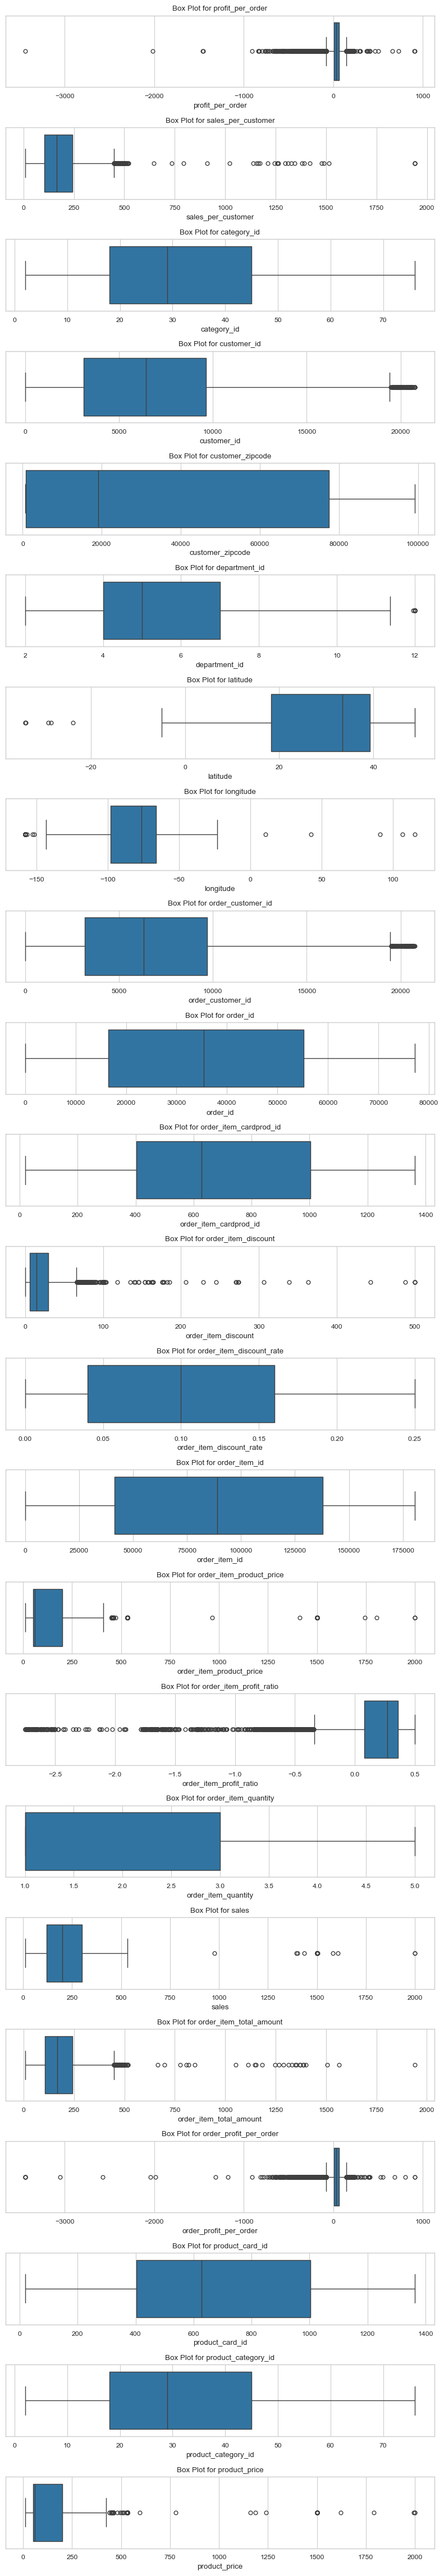

In [160]:
## Detecting outliers on numerical columns

# Filter numerical columns for box plots
numerical_features = log_df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(8, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=log_df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

### Handling Outliers Using IQR (Interquartile Range)

In [161]:
# Define the IQR Outlier Removal Function
def remove_outliers_iqr(log_df, column):
    Q1 = log_df[column].quantile(0.25)
    Q3 = log_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return log_df[(log_df[column] >= lower_bound) & (log_df[column] <= upper_bound)]

log_df = log_df
numerical_columns = log_df.select_dtypes(include=['number']).columns

for col in numerical_columns:
    log_df = remove_outliers_iqr(log_df, col)

### Rechecking the presence of Outliers after Treatment

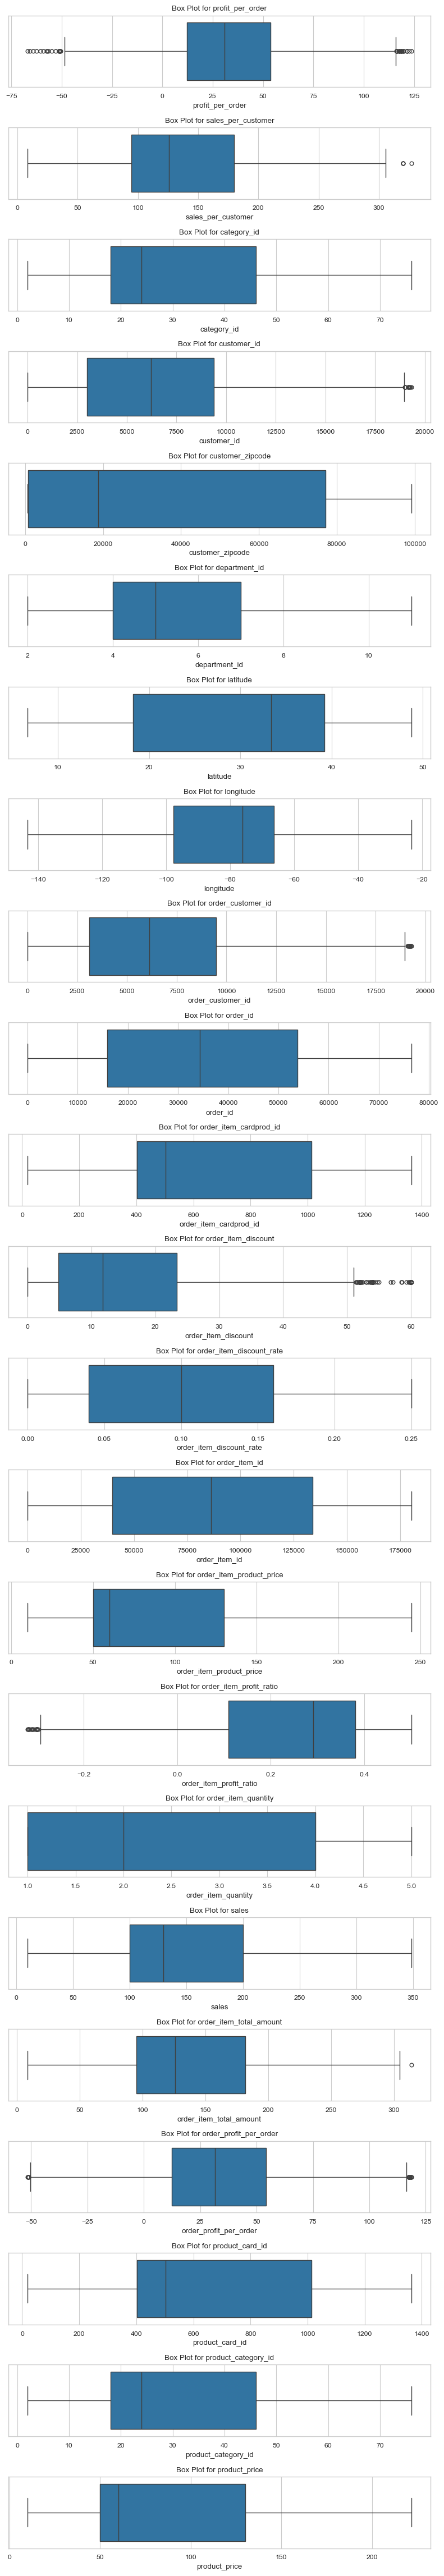

In [162]:
## Detecting outliers on numerical columns

# Filter numerical columns for box plots
numerical_features = log_df.select_dtypes(include=['number']).columns

# Plot box plots for each numerical feature
plt.figure(figsize=(8, len(numerical_features) * 2))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(len(numerical_features), 1, i)
    sns.boxplot(x=log_df[col])
    plt.title(f"Box Plot for {col}")
    plt.tight_layout()

plt.show()

#the job of enumerate(numerical_features, 1)
#is to loop over the list 'numerical_features' while also keeping track of an index i starting from 1.

**Comment**: The outliers have been handled successfully!

## Exploratory Data Analysis (EDA)

## Univariate Analysis

In [84]:
## Create a function for numerical analysis

# Select numeric columns
num_df = log_df.select_dtypes(include=['number'])

def num_univariate_analysis(discrete_data):
    for col_name in discrete_data:
        print("*"*5, col_name, "*"*5)
        print(discrete_data[col_name].agg(['min', 'max', 'mean', 'median', 'std', 'kurt', 'skew']))
        print()

num_univariate_analysis(num_df)

***** profit_per_order *****
min       -66.965970
max       123.619250
mean       33.565794
median     30.893501
std        30.619826
kurt       -0.132387
skew        0.187884
Name: profit_per_order, dtype: float64

***** sales_per_customer *****
min         8.351162
max       326.925320
mean      134.431066
median    125.947195
std        62.194219
kurt       -0.495032
skew        0.230688
Name: sales_per_customer, dtype: float64

***** category_id *****
min        2.000000
max       76.000000
mean      28.611368
median    24.000000
std       13.794571
kurt      -0.545504
skew       0.606459
Name: category_id, dtype: float64

***** customer_id *****
min           1.108005
max       19315.244000
mean       6309.056777
median     6203.007150
std        3822.509835
kurt         -0.589376
skew          0.261313
Name: customer_id, dtype: float64

***** customer_zipcode *****
min         603.613100
max       99104.125000
mean      34689.177759
median    18814.961500
std       37107.071926
k

### Distribution of Numerical features - Histogram Plot

In [88]:
log_df.select_dtypes(include=['number']).columns

Index(['profit_per_order', 'sales_per_customer', 'category_id', 'customer_id',
       'customer_zipcode', 'department_id', 'latitude', 'longitude',
       'order_customer_id', 'order_id', 'order_item_cardprod_id',
       'order_item_discount', 'order_item_discount_rate', 'order_item_id',
       'order_item_product_price', 'order_item_profit_ratio',
       'order_item_quantity', 'sales', 'order_item_total_amount',
       'order_profit_per_order', 'product_card_id', 'product_category_id',
       'product_price'],
      dtype='object')

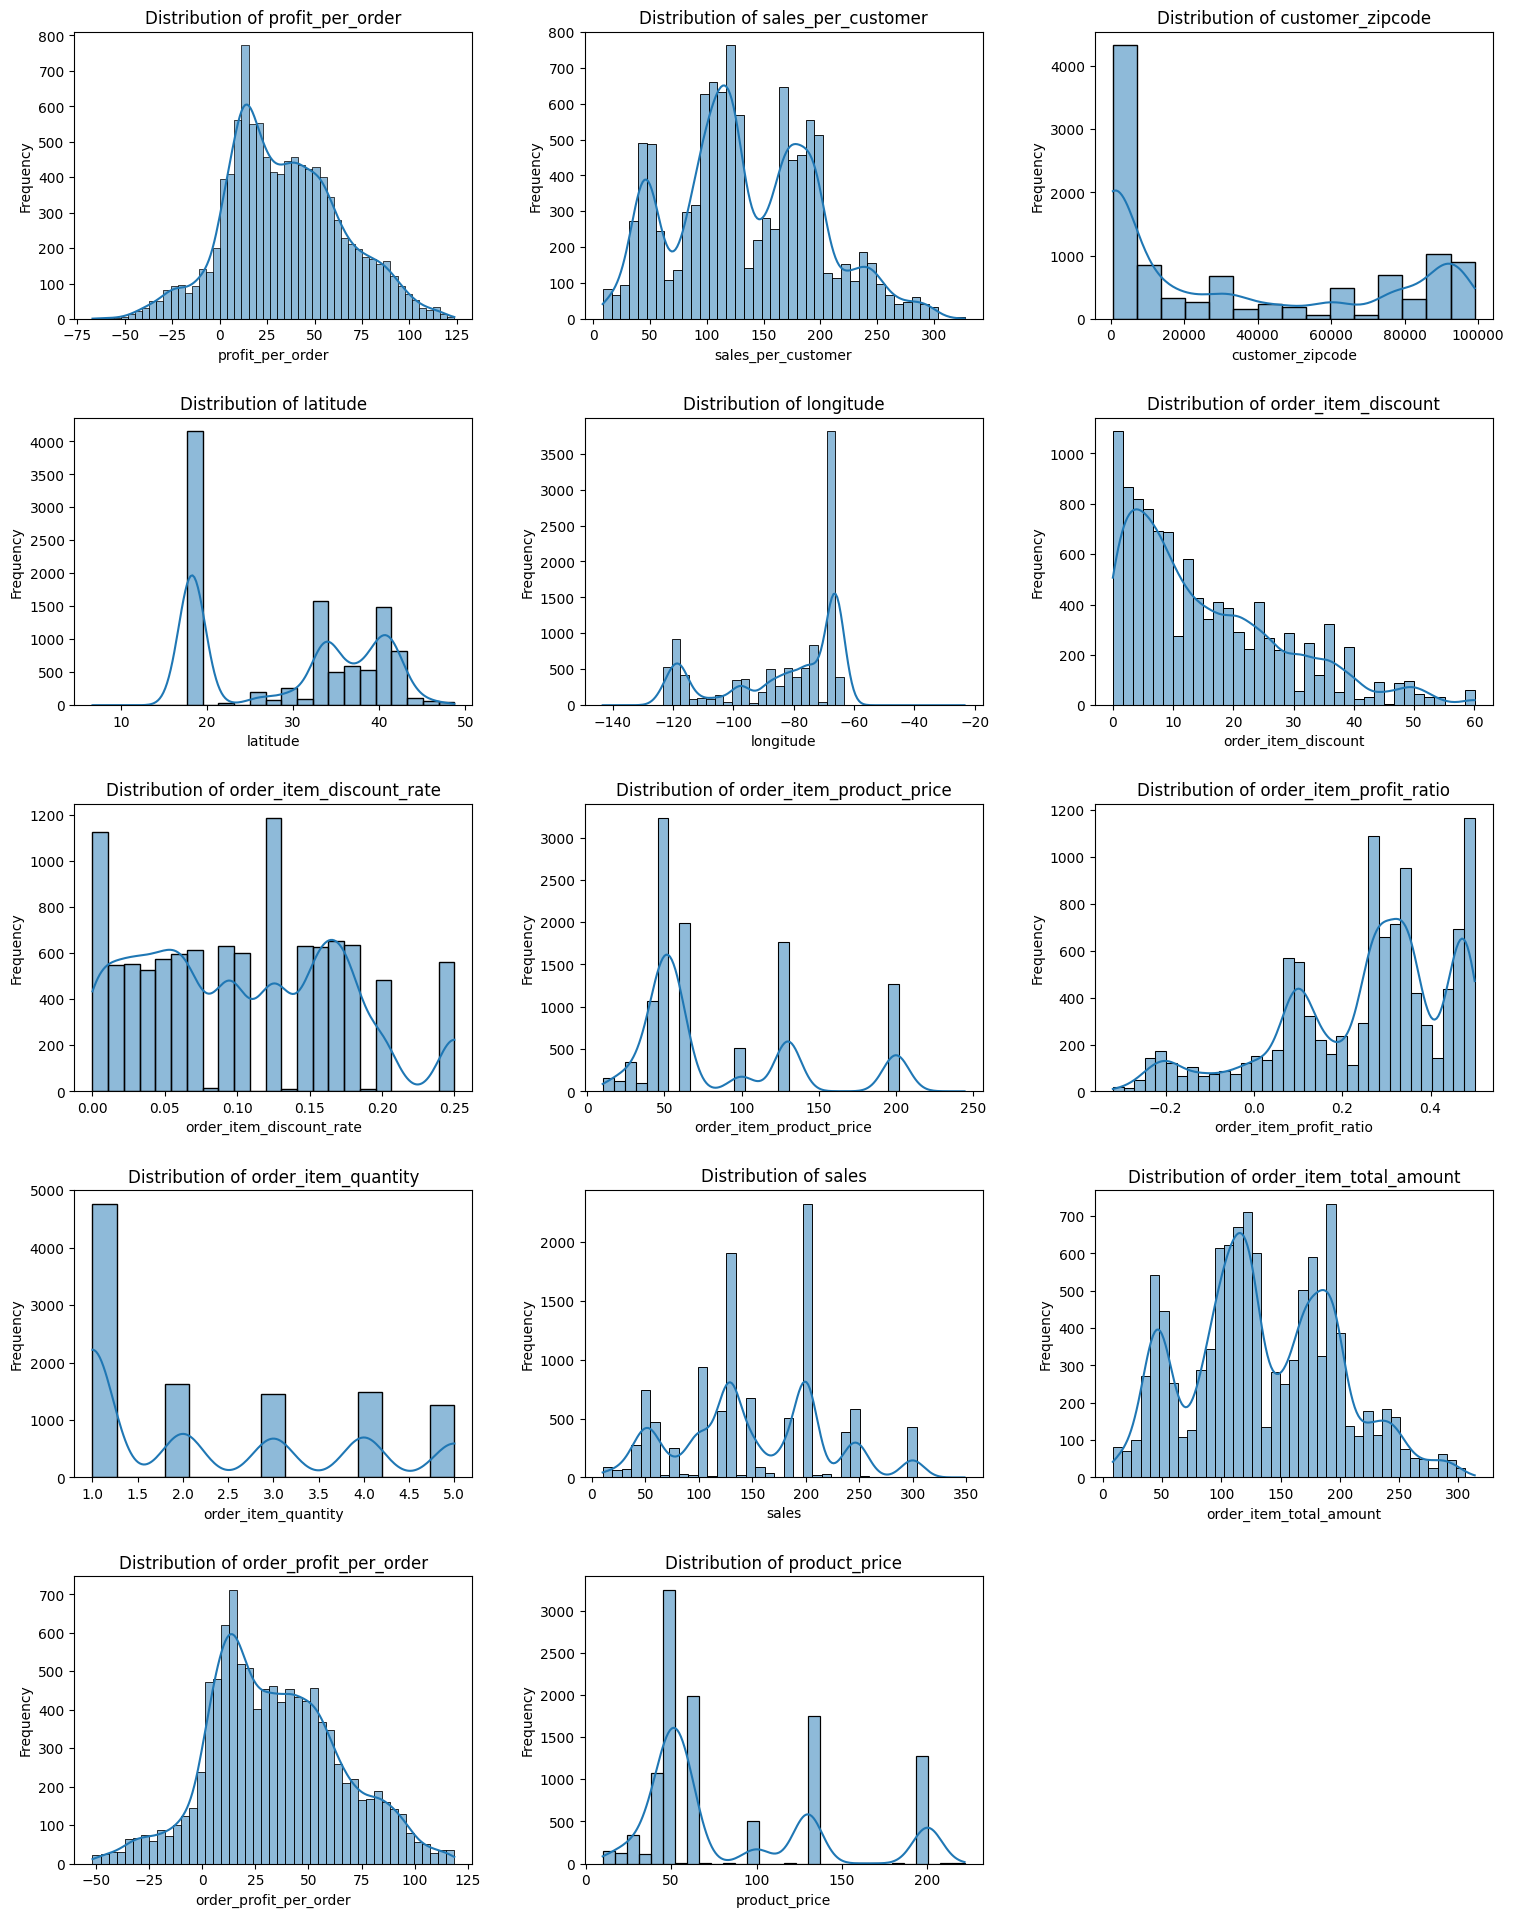

In [97]:
import math

# creating a function to plot the distribution of the variables
def univariate_analysis(num_cols_for_plotting_df):
    num_cols = len(num_cols_for_plotting_df.columns)
    ncols = 3
    nrows = math.ceil(num_cols / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
    fig.tight_layout(pad=5.0)

    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col_name in enumerate(num_cols_for_plotting_df.columns):
        sns.histplot(data=num_cols_for_plotting_df, x=col_name, kde=True, ax=axes[i]) # We used KDE for a smooth distribution curve
        axes[i].set_title(f'Distribution of {col_name}')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('Frequency')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

# select numerical columns only
num_cols = log_df.select_dtypes(include=['float64', 'int64']).columns

# list of id columns to exclude in our plot (they are not important for the Histogram plot)
id_cols_to_exclude = ['category_id', 'customer_id', 'department_id', 'order_customer_id', 'order_id',
                      'order_item_cardprod_id', 'order_item_id', 'product_card_id', 'product_category_id']

# Filter out the ID columns from the numerical columns
num_cols_to_plot = [col for col in num_cols if col not in id_cols_to_exclude]

# Create a dataframe of the numerical columns without the id columns for plotting
num_cols_for_plotting_df = log_df[num_cols_to_plot]
univariate_analysis(num_cols_for_plotting_df)

In [99]:
# let's create a function for categorical analysis
cat_df = log_df.select_dtypes(include=['object'])

def cat_univariate_analysis(discrete_data):
    for col_name in discrete_data:
        print("*"*5, col_name, "*"*5)
        print(discrete_data[col_name].agg(['count', 'nunique', 'unique']))
        print()
        print('Value Counts: \n', discrete_data[col_name].value_counts())
        print()

cat_univariate_analysis(cat_df)

***** payment_type *****
count                                 10596
nunique                                   4
unique     [DEBIT, TRANSFER, CASH, PAYMENT]
Name: payment_type, dtype: object

Value Counts: 
 payment_type
DEBIT       4217
PAYMENT     2646
TRANSFER    2521
CASH        1212
Name: count, dtype: int64

***** category_name *****
count                                                  10596
nunique                                                   46
unique     [Cardio Equipment, Water Sports, Indoor/Outdoo...
Name: category_name, dtype: object

Value Counts: 
 category_name
Cleats                  1874
Men's Footwear          1726
Women's Apparel         1672
Indoor/Outdoor Games    1479
Water Sports            1239
Shop By Sport            922
Cardio Equipment         497
Electronics              187
Accessories              110
Golf Balls               102
Golf Gloves               86
Girls' Apparel            66
Trade-In                  54
Baseball & Softball       43
Cra

## Bivariate and Multivariate Analysis

### Categorical Variables vs Target Variable (delivery_delay_status)

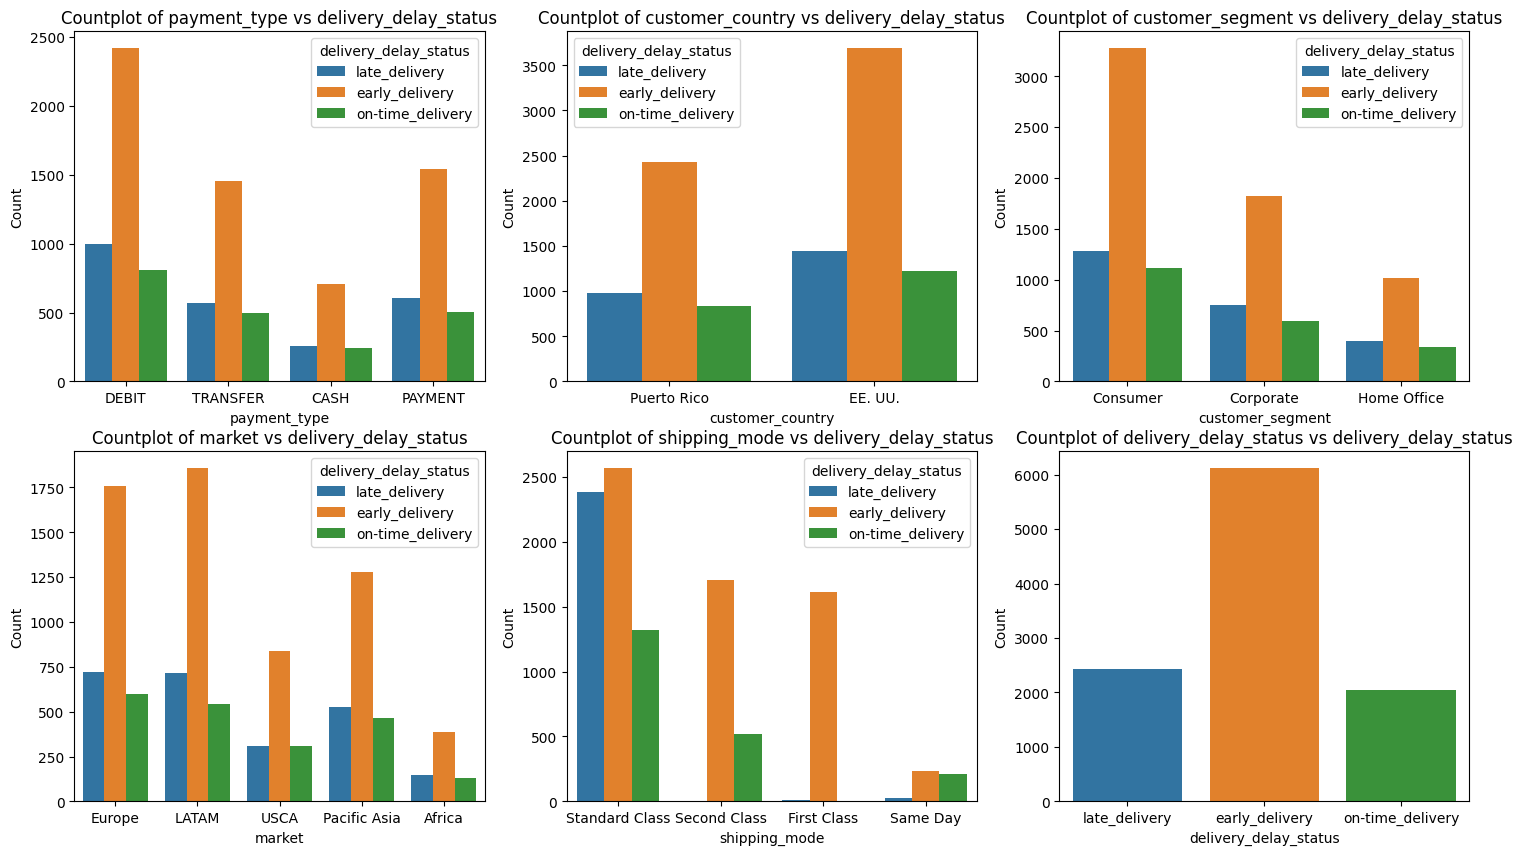

In [105]:
# Filter categorical columns with low cardinality
cat_df = [col for col in log_df.select_dtypes(include=['object']).columns if log_df[col].nunique() <= 6]

# creating a function to plot the distribution of the variables
def bivariate_analysis(log_df):
    cat_cols = len(cat_df)
    ncols = 3
    nrows = math.ceil(cat_cols / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))

    axes = axes.flatten() # Flatten axes array for easy iteration

    for i, col_name in enumerate(cat_df):
        sns.countplot(data=log_df, x=col_name, hue='delivery_delay_status', ax=axes[i])
        axes[i].set_title(f'Countplot of {col_name} vs delivery_delay_status')
        axes[i].set_xlabel(col_name)
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.show()

bivariate_analysis(log_df)

### Correlation Matrix - Checking the relationship between numerical variables

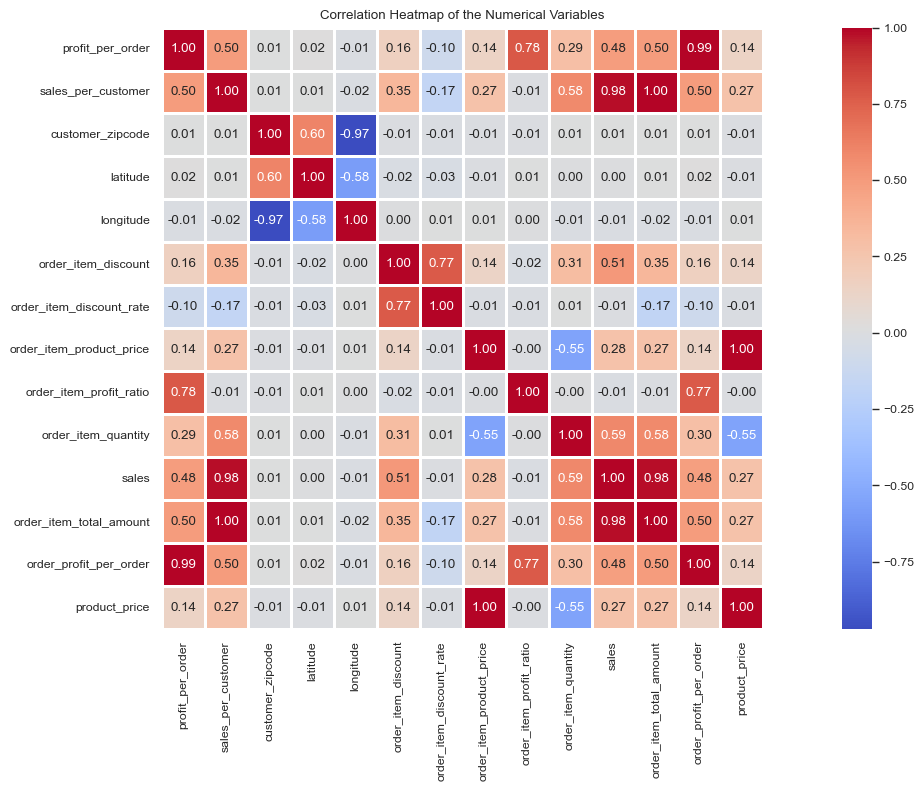

In [163]:
# Using heatmap to show correlation matrix
corr = num_cols_for_plotting_df.corr(numeric_only=True)

plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1.0, square=True)
plt.title("Correlation Heatmap of the Numerical Variables")

plt.tight_layout()
plt.show()

In [115]:
cat_df = log_df.select_dtypes(include=['object']).columns
print(cat_df)

Index(['payment_type', 'category_name', 'customer_city', 'customer_country',
       'customer_segment', 'customer_state', 'department_name', 'market',
       'order_city', 'order_country', 'order_region', 'order_state',
       'order_status', 'product_name', 'shipping_mode',
       'delivery_delay_status'],
      dtype='object')


## Where are the Sales coming from? - We want to know the countries where the orders are from

,customer_country,customer_segment,customer_city
0,Puerto Rico,Consumer,Caguas
1,EE. UU.,Consumer,Albuquerque
2,Puerto Rico,Consumer,Amarillo
4,EE. UU.,Consumer,Peabody
5,Puerto Rico,Consumer,Caguas


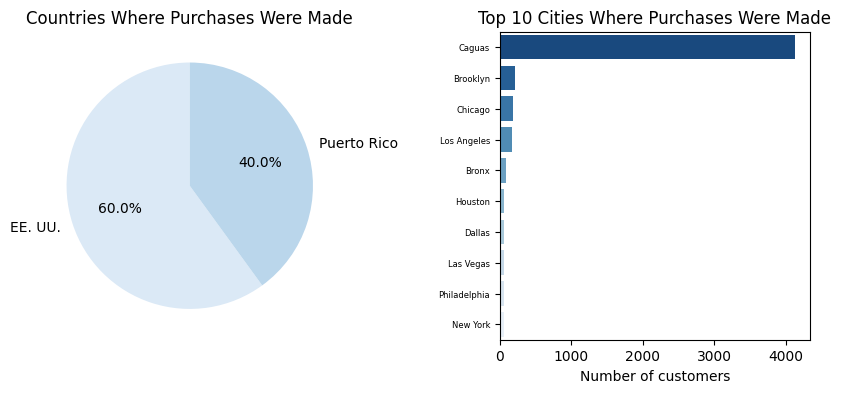

In [121]:
## Which countries are the orders coming from, and from which customers?

# Creates a dataframe that displays all countries in the dataset and the number of times they appeared
countries_and_customers = log_df[["customer_country", "customer_segment", "customer_city"]]

display(countries_and_customers.head())


# Visualizing countries and cities
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# group customers by their countries
customers_by_countries = countries_and_customers.groupby("customer_country").count()

# group top 10 customers by their cities
top_customer_cities = countries_and_customers.groupby("customer_city").count().sort_values("customer_segment", ascending=False).head(10)

#display(customers_by_countries, customers_by_cities)

ax[0].pie(customers_by_countries["customer_city"], labels=customers_by_countries.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Blues'))
ax[0].set_title("Countries Where Purchases Were Made")

sns.barplot(
    data=top_customer_cities,
    x="customer_segment",
    y=top_customer_cities.index,
    ax=ax[1],
    palette="Blues_r"
).set(xlabel="Number of customers", ylabel="")

ax[1].set_title("Top 10 Cities Where Purchases Were Made")
ax[1].tick_params(axis="y", labelsize=6)

plt.subplots_adjust(wspace=0.5)
plt.savefig("Customer_countries_of_origin.png")
plt.show()

In [123]:
store_data = log_df[["department_name", 
          "longitude", 
          "latitude",
          "sales",
          "customer_country",
          "sales_per_customer",
          "customer_segment",
          "profit_per_order", 
          "category_name", 
          "order_item_discount",
          "order_item_discount_rate",
          "order_item_product_price",
          "order_item_quantity",
          "order_item_total_amount",
          "order_profit_per_order",
          "order_region",
          "order_city", 
          "order_country",
          "order_status",
          "product_name",
          "product_price",
          "shipping_mode",
          "delivery_delay_status"
         ]]

### Purchases according customer department and customer segment

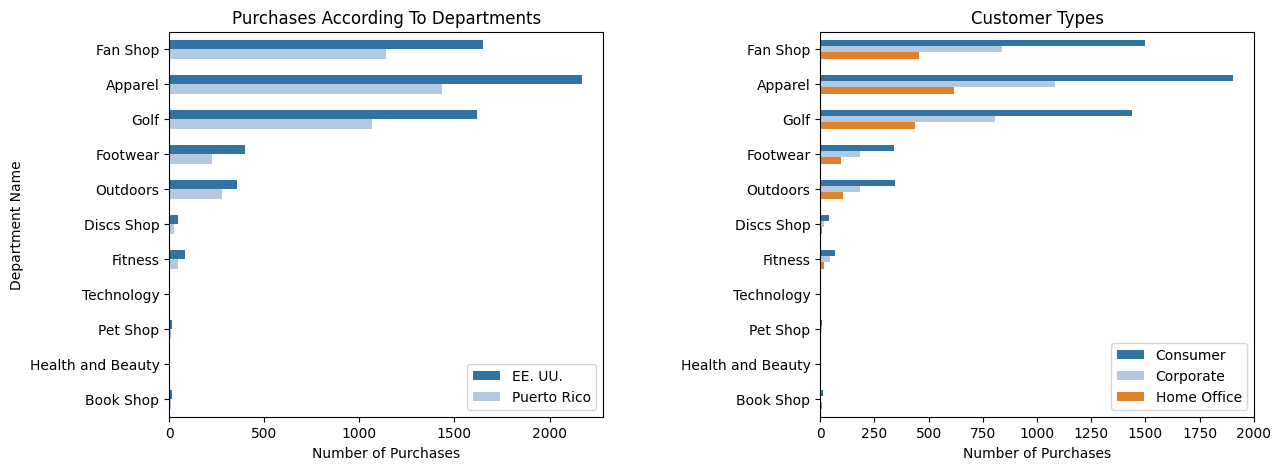

In [125]:
# Visualizing Store Locations according to number of purchases made
palette = sns.color_palette("dark:#5A9_r", as_cmap=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=store_data,
    y="department_name",
    hue="customer_country",
    order=["Fan Shop", "Apparel", "Golf", "Footwear", "Outdoors", "Discs Shop", "Fitness", "Technology", "Pet Shop", "Health and Beauty", "Book Shop"],
    hue_order=["EE. UU.", "Puerto Rico"],
    width=.55,
    palette="tab20",
    ax=ax[0]
).set(title="Purchases According To Departments", xlabel="Number of Purchases", ylabel="Department Name")

ax[0].legend(loc="lower right")

sns.countplot(
    data=store_data,
    y="department_name",
    hue="customer_segment",
    order=["Fan Shop", "Apparel", "Golf", "Footwear", "Outdoors", "Discs Shop", "Fitness", "Technology", "Pet Shop", "Health and Beauty", "Book Shop"],
#     hue_order=["EE. UU.", "Puerto Rico"],
    width=.55,
    palette="tab20",
    ax=ax[1]
).set(title="Customer Types", xlabel="Number of Purchases", ylabel="")

ax[1].legend(loc="lower right")

plt.subplots_adjust(wspace=0.5)
plt.savefig("Purchases_from_dept.png")
plt.show()

### Best selling products by departments

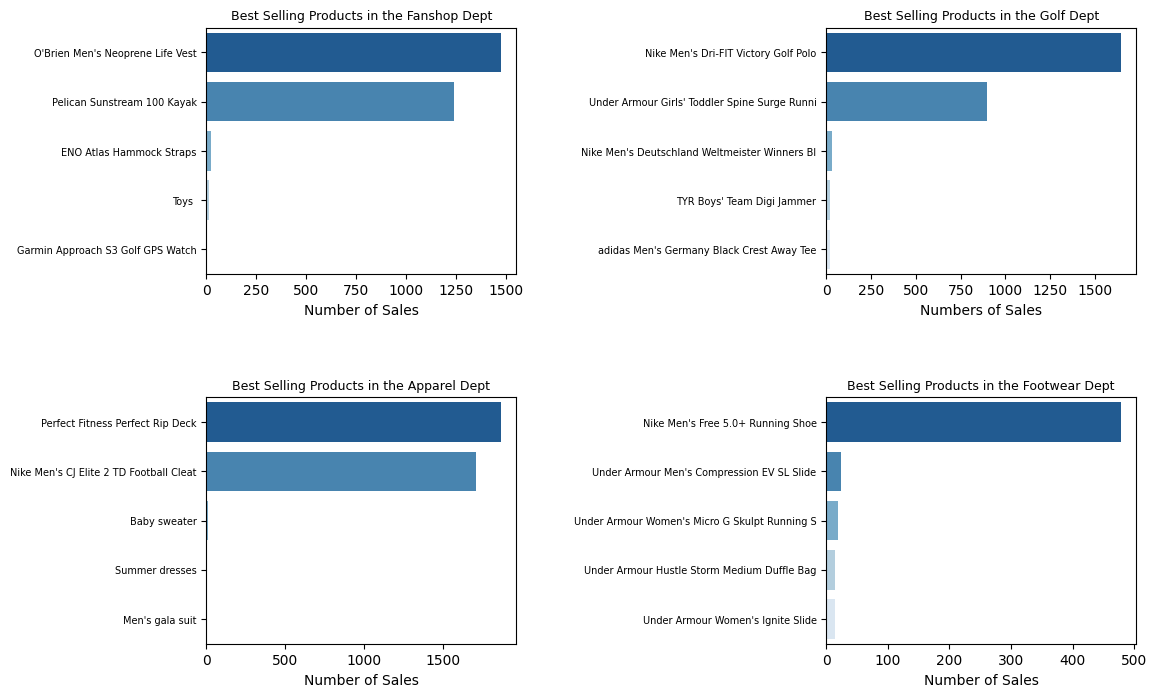

In [126]:
products_fan_shops = store_data[store_data["department_name"] == "Fan Shop"].groupby("product_name").count().sort_values("sales", ascending=False).head()

apparel_products = store_data[store_data["department_name"] == "Apparel"].groupby("product_name").count().sort_values("sales", ascending=False).head()

products_golf = store_data[store_data["department_name"] == "Golf"].groupby("product_name").count().sort_values("sales", ascending=False).head(5)

products_footwear = store_data[store_data["department_name"] == "Footwear"].groupby("product_name").count().sort_values("sales", ascending=False).head(5)

fig, ax = plt.subplots(2,2, figsize=(12, 8))

sns.barplot(
    data=products_fan_shops,
    y=products_fan_shops.index,
    x="sales",
    palette="Blues_r",
    ax=ax[0, 0]
).set(xlabel="Number of Sales", ylabel="")
ax[0, 0].tick_params(axis="y", labelsize=7)
ax[0, 0].set_title("Best Selling Products in the Fanshop Dept", fontsize=9)

sns.barplot(
    data=products_golf,
    y=products_golf.index,
    x="sales",
    palette="Blues_r",
    ax=ax[0, 1]
).set(xlabel="Numbers of Sales", ylabel="")
ax[0, 1].tick_params(axis="y", labelsize=7)
ax[0, 1].set_title("Best Selling Products in the Golf Dept", fontsize=9)

sns.barplot(
    data=apparel_products,
    y=apparel_products.index,
    x="sales",
    palette="Blues_r",
    ax=ax[1, 0]
).set(xlabel="Number of Sales", ylabel="")
ax[1, 0].tick_params(axis="y", labelsize=7)
ax[1, 0].set_title("Best Selling Products in the Apparel Dept", fontsize=9)

sns.barplot(
    data=products_footwear,
    y=products_footwear.index,
    x="sales",
    palette="Blues_r",
    ax=ax[1, 1]
).set(xlabel="Number of Sales", ylabel="")
ax[1, 1].tick_params(axis="y", labelsize=7)
ax[1, 1].set_title("Best Selling Products in the Footwear Dept", fontsize=9)


plt.subplots_adjust(wspace=1, hspace=0.5)
plt.savefig("best_selling_products_each_dept.png")
plt.show()

## Which Products Sell the Most?

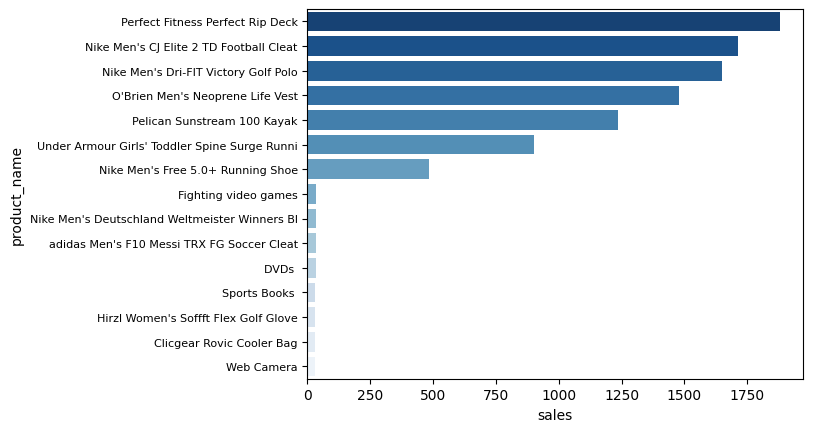

In [128]:
best_selling_products = store_data.groupby("product_name").count().sort_values("longitude", ascending=False)

sns.barplot(
    data=best_selling_products.head(15),
    y=best_selling_products.head(15).index,
    x="sales",
    palette="Blues_r"
)
plt.tick_params(axis="y", labelsize=8)
plt.savefig("best_selling_products.png")

### Where do the products go to? - *`Which markets are the orders delivered to?`*

,customer_segment
market,
LATAM,3115
Europe,3079
Pacific Asia,2274
USCA,1459
Africa,669


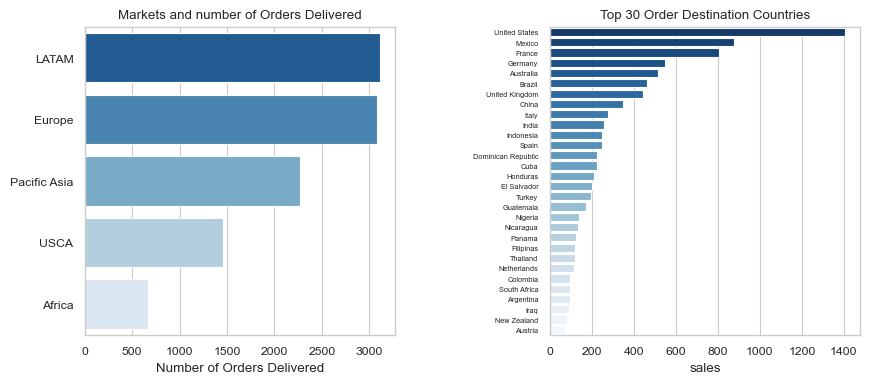

In [130]:
# Which markets are the orders delivered to?
markets = log_df[["market", "customer_segment"]]
order_countries = log_df.groupby("order_country").count().sort_values("delivery_delay_status", ascending=False) # The sorting column was arbitrary.
markets_grouped = markets.groupby(["market"]).count().sort_values('customer_segment', ascending=False)
display(markets_grouped)

# Visualizing the size and customers from each market
sns.set_style("whitegrid")
sns.set_context("paper")

## Instantiating the plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(
    data=markets_grouped,
    x="customer_segment",
    y=markets_grouped.index,
    palette="Blues_r",
    ax=ax[0]
).set(xlabel="Number of Orders Delivered", title="Markets and number of Orders Delivered", ylabel="")


sns.barplot(
    data=order_countries.head(30),
    y=order_countries.head(30).index,
    x="sales",
    palette="Blues_r",
    ax=ax[1]
).set(title="Top 30 Order Destination Countries", ylabel="")

ax[1].tick_params(axis="y", labelsize=5.3)

plt.subplots_adjust(wspace=0.5)
plt.savefig("order_destinations.png")
plt.show()

## Tracing Factors Causing Order Delays

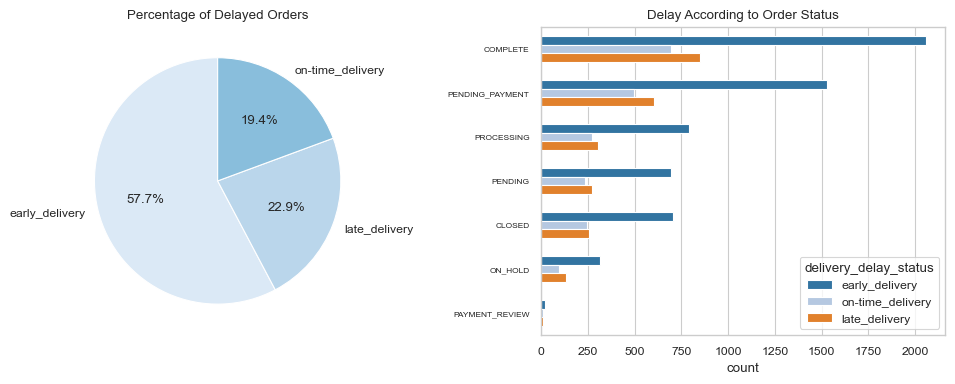

In [168]:
# Percentage of Delayed orders 
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].pie(log_df.groupby("delivery_delay_status").count().sort_values("sales", ascending=False)["sales"], labels=log_df.groupby("delivery_delay_status").count().sort_values("sales", ascending=False).index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Blues'))
ax[0].set_title("Percentage of Delayed Orders")

sns.countplot(
    data=log_df,
    y="order_status",
    hue="delivery_delay_status",
    palette="tab20",
    ax=ax[1],
    order=["COMPLETE", "PENDING_PAYMENT", "PROCESSING", "PENDING", "CLOSED", "ON_HOLD", "PAYMENT_REVIEW"],
    hue_order=["early_delivery", "on-time_delivery", "late_delivery"],
    width=.6
).set(ylabel="", title="Delay According to Order Status")

ax[1].tick_params(axis="y", labelsize=6)

plt.subplots_adjust(wspace=0.3)
plt.savefig("percentage_of_delayed_orders.png")
plt.show()

### Delayed Orders vs Purchase by Countries and Regions

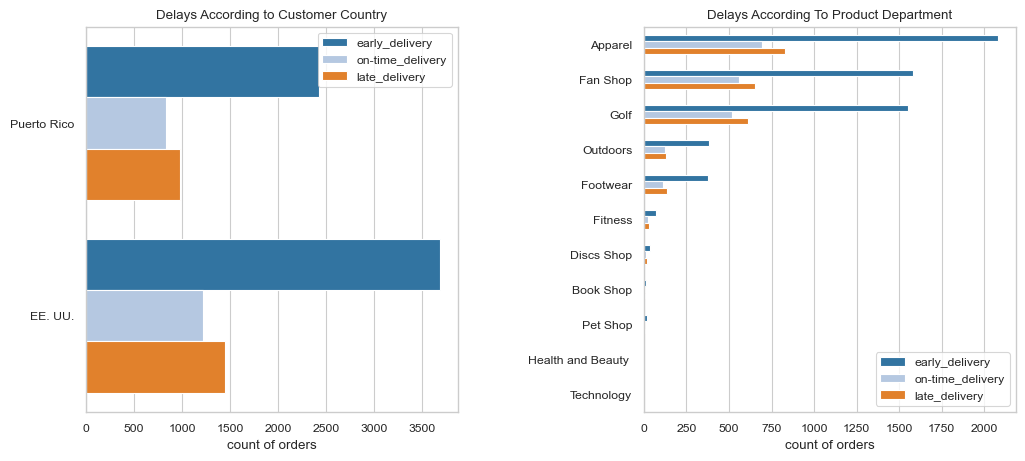

In [171]:
# Delayed orders vs Purchase by countries and regions
purchases_from_departments = log_df.groupby("department_name").count().sort_values("delivery_delay_status", ascending=False).index

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=log_df,
    y="department_name",
    hue="delivery_delay_status",
    order=purchases_from_departments,
    palette="tab20",
    ax=ax[1],
    hue_order=["early_delivery", "on-time_delivery", "late_delivery"],
    width=0.55
).set(title="Delays According To Product Department", ylabel="", xlabel="count of orders")

ax[1].legend(loc="lower right")

sns.countplot(
    data=log_df,
    y="customer_country",
    hue="delivery_delay_status",
    palette="tab20",
    ax=ax[0],
    hue_order=["early_delivery", "on-time_delivery", "late_delivery"],
    width=0.8
).set(title="Delays According to Customer Country", ylabel="", xlabel="count of orders")

ax[0].legend(loc="upper right")

plt.subplots_adjust(wspace=0.5)
plt.savefig("delays_vs_customer_country_and_prod_dept.png")
plt.show()

### Delays According to Customer and Payment Types

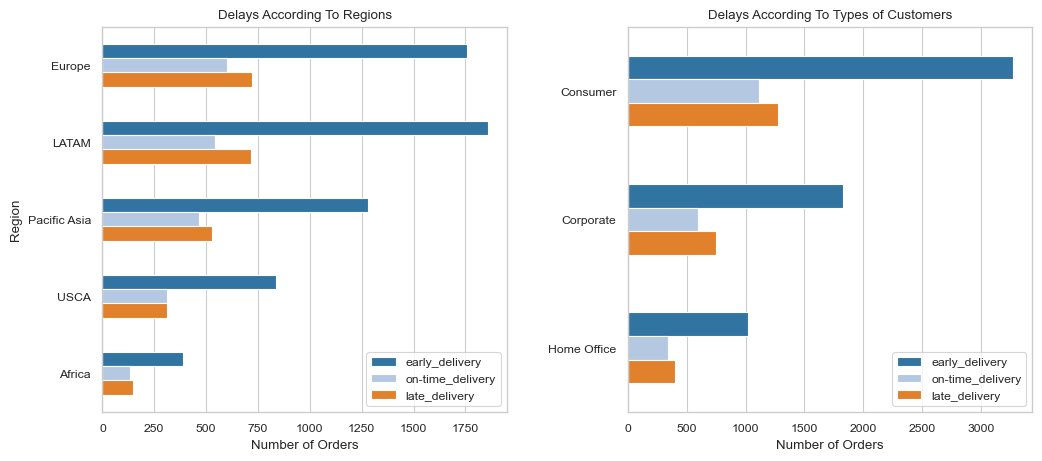

In [172]:
# Delays According to customer and payment types

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=log_df,
    y="market",
    hue="delivery_delay_status",
    order=["Europe", "LATAM", "Pacific Asia", "USCA", "Africa"],
    hue_order=["early_delivery", "on-time_delivery", "late_delivery"],
    width=.55,
    palette="tab20",
    ax=ax[0]
).set(title="Delays According To Regions", xlabel="Number of Orders", ylabel="Region")

ax[0].legend(loc="lower right")

sns.countplot(
    data=log_df,
    y="customer_segment",
    hue="delivery_delay_status",
#     order=["DEBIT", "PAYMENT", "TRANSFER", "CASH"],
    hue_order=["early_delivery", "on-time_delivery", "late_delivery"],
    width=.55,
    palette="tab20",
    ax=ax[1]
).set(title="Delays According To Types of Customers", xlabel="Number of Orders", ylabel="")

ax[1].legend(loc="lower right")

plt.subplots_adjust(wspace=0.3)
plt.savefig("delays_according_to_regions_and_customers.png")
plt.show()

In [173]:
# Count Delayed Orders
count_delayed_orders = log_df.shape[0] * 0.577

count_delayed_orders

6113.892

## Feature Engineering

### Calculating Shipping Delays

In [174]:
# Dropping rows with "NaT" values in order_date and shipping_date column
log_df = log_df.dropna(subset=["order_date", "shipping_date"])

## Calculating Shipping delays

# Calculate the delay as the difference between shipping and order dates
log_df.loc[:, ['shipping_duration']] = (log_df['shipping_date'] - log_df['order_date']).dt.days

# Filter rows where shipping_duration is greater than a threshold
delayed_orders = log_df[
    (log_df['shipping_duration'] > 7) & 
    (log_df["delivery_delay_status"] == "late_delivery") & 
    (log_df["order_status"] != "PENDING_PAYMENT") & 
    (log_df["order_status"] != "PENDING")
]

sample = delayed_orders[["shipping_duration", "product_name", "order_status", "order_country", "order_region", "delivery_delay_status"]]

count_treatable_delays = sample.shape[0]

display(count_treatable_delays)

percent_treatable_delays = (sample.shape[0] / log_df.shape[0]) * 100

display(percent_treatable_delays)

sample

836

7.889769724424312

,shipping_duration,product_name,order_status,order_country,order_region,delivery_delay_status
17,22,Team Golf St. Louis Cardinals Putter Grip,COMPLETE,Italy,Southern Europe,late_delivery
20,41,Nike Men's CJ Elite 2 TD Football Cleat,COMPLETE,United Kingdom,Northern Europe,late_delivery
28,27,Nike Men's CJ Elite 2 TD Football Cleat,COMPLETE,Cuba,Caribbean,late_delivery
38,95,Fighting video games,CLOSED,United States,East of USA,late_delivery
72,127,Pelican Sunstream 100 Kayak,COMPLETE,Filipinas,Southeast Asia,late_delivery
...,...,...,...,...,...,...
15515,91,Pelican Sunstream 100 Kayak,ON_HOLD,Tanzania,East Africa,late_delivery
15517,25,Nike Men's Dri-FIT Victory Golf Polo,CLOSED,Ukraine,Eastern Europe,late_delivery
15527,33,Perfect Fitness Perfect Rip Deck,COMPLETE,Argelia,North Africa,late_delivery
15539,48,Nike Men's CJ Elite 2 TD Football Cleat,COMPLETE,Venezuela,South America,late_delivery


In [175]:
# Group delays by regions, cities, or countries
delay_by_region = delayed_orders.groupby('order_region')['shipping_duration'].median().sort_values(ascending=False)
delay_by_country = delayed_orders.groupby('order_country')['shipping_duration'].median().sort_values(ascending=False)

display(delay_by_region)
display(delay_by_country)

order_region
South of  USA      78.0
US Center          67.0
Southern Africa    64.5
Caribbean          60.0
Eastern Asia       57.0
West of USA        56.0
Northern Europe    56.0
Central Africa     53.0
Canada             52.5
Eastern Europe     52.5
Southern Europe    52.0
South America      52.0
South Asia         52.0
North Africa       48.0
East of USA        46.5
Western Europe     46.0
Central America    44.5
West Africa        42.5
East Africa        41.0
West Asia          41.0
Oceania            41.0
Central Asia       38.0
Southeast Asia     37.0
Name: shipping_duration, dtype: float64

order_country
Belice                 128.0
Uzbekistan             110.0
Guadalupe              109.0
Haiti                  106.0
Slovakia                96.0
                       ...  
Libya                   19.0
Martinica               18.0
Cameroon                16.0
Japan                   14.0
Trinidad and Tobago      9.0
Name: shipping_duration, Length: 82, dtype: float64

### Average Shipping Day for Delayed Products

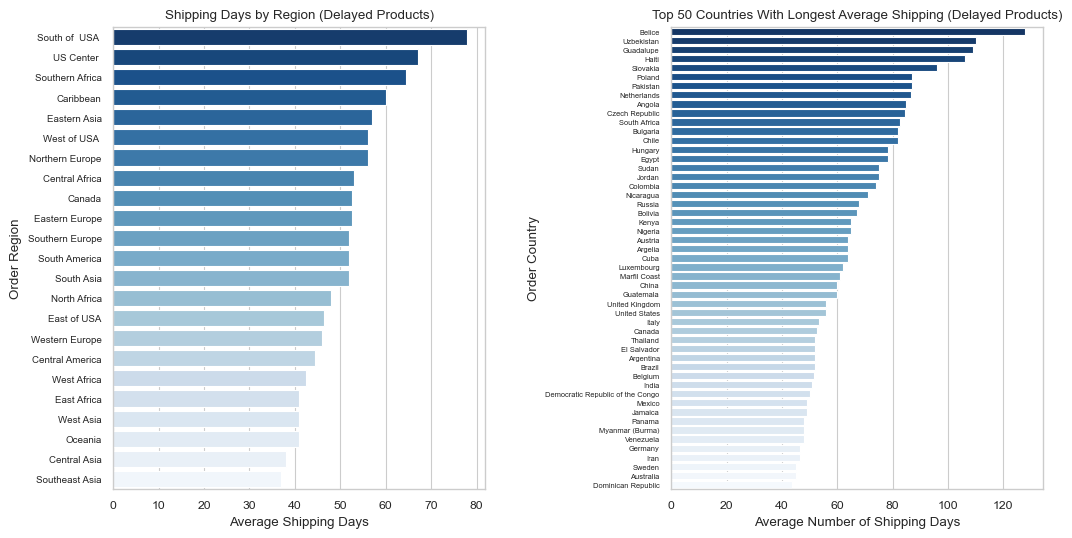

In [178]:
# Average shipping day for delayed products
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(
    y=delay_by_region.index, 
    x=delay_by_region.values, 
    palette="Blues_r",
    ax=ax[0]
).set(ylabel="Order Region")
ax[0].tick_params(axis="y", labelsize=7)
ax[0].set_title("Shipping Days by Region (Delayed Products)")
ax[0].set_xlabel("Average Shipping Days")

sns.barplot(
    y=delay_by_country[:51].index, 
    x=delay_by_country[:51].values, 
    palette="Blues_r",
    ax=ax[1]
).set(ylabel="Order Country", 
      xlabel="Average Number of Shipping Days", 
      title="Top 50 Countries With Longest Average Shipping (Delayed Products)"
     )

ax[1].tick_params(axis="y", labelsize=5.4)
plt.subplots_adjust(wspace=0.5)
plt.savefig("shipping_days_by_region.png")
plt.show()

### Average Shipping Days Overall

In [179]:
log_df.head()

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_state,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,delivery_delay_status,shipping_duration
0,DEBIT,34.448338,92.49099,9.0,Cardio Equipment,Caguas,Puerto Rico,12097.6830,Consumer,PR,...,Vienna,COMPLETE,191.00000,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2015-08-12 23:00:00+00:00,Standard Class,late_delivery,1
1,TRANSFER,91.193540,181.99008,48.0,Water Sports,Albuquerque,EE. UU.,5108.1045,Consumer,CA,...,Buenos Aires,PENDING,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2017-04-08 23:00:00+00:00,Standard Class,late_delivery,57
2,DEBIT,8.313806,89.96643,46.0,Indoor/Outdoor Games,Amarillo,Puerto Rico,4293.4478,Consumer,PR,...,Nord-Pas-de-Calais-Picardy,COMPLETE,1014.00000,46.0,O'Brien Men's Neoprene Life Vest,49.98,2015-03-18 00:00:00+00:00,Second Class,early_delivery,76
4,DEBIT,44.722590,170.97824,48.0,Water Sports,Peabody,EE. UU.,1546.3980,Consumer,CA,...,Illinois,COMPLETE,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2015-03-29 23:00:00+00:00,Standard Class,early_delivery,1
5,CASH,76.100400,137.45360,17.0,Electronics,Caguas,Puerto Rico,5048.3975,Consumer,PR,...,Pennsylvania,CLOSED,209.90128,9.0,Under Armour Women's Ignite PIP VI Slide,39.99,2016-10-13 23:00:00+00:00,Standard Class,early_delivery,130


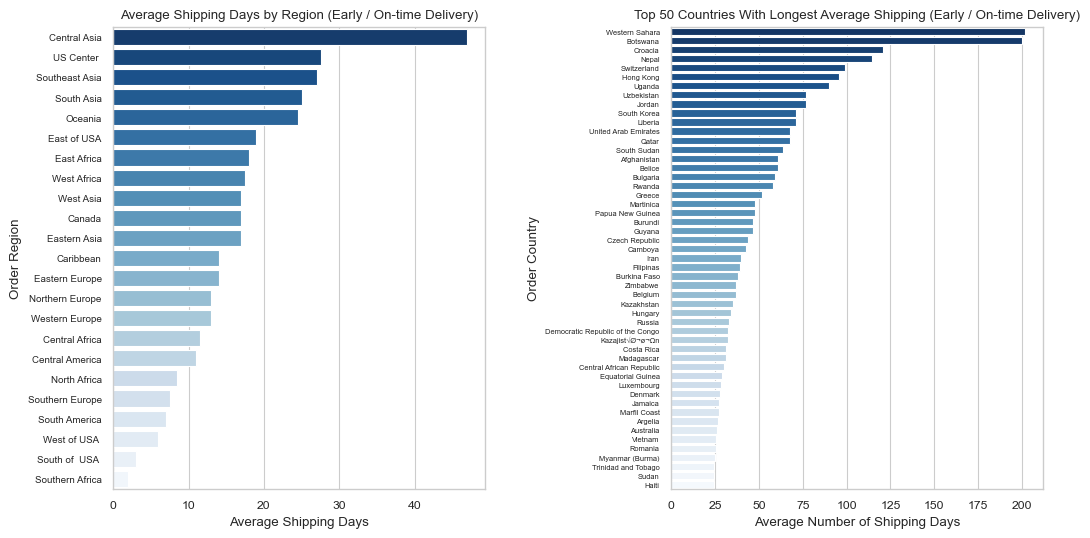

In [180]:
# Average Shipping days overall
shipping_by_region = log_df[log_df["delivery_delay_status"] != "late_delivery"].groupby('order_region')['shipping_duration'].median().sort_values(ascending=False)
shipping_by_country = log_df[log_df["delivery_delay_status"] != "late_delivery"].groupby('order_country')['shipping_duration'].median().sort_values(ascending=False)

shipping_by_region
shipping_by_country[:51]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(
    y=shipping_by_region.index, 
    x=shipping_by_region.values, 
    palette="Blues_r",
    ax=ax[0]
).set(ylabel="Order Region")

ax[0].tick_params(axis="y", labelsize=7)
ax[0].set_title("Average Shipping Days by Region (Early / On-time Delivery)")
ax[0].set_xlabel("Average Shipping Days")

sns.barplot(
    y=shipping_by_country[:51].index, 
    x=shipping_by_country[:51].values, 
    palette="Blues_r",
    ax=ax[1]
).set(ylabel="Order Country", 
      xlabel="Average Number of Shipping Days", 
      title="Top 50 Countries With Longest Average Shipping (Early / On-time Delivery)"
     )

ax[1].tick_params(axis="y", labelsize=5.4)
plt.subplots_adjust(wspace=0.5)
plt.savefig("shipping_days_by_region.png")
plt.show()

### Delays by Shipping Mode and Payment Type

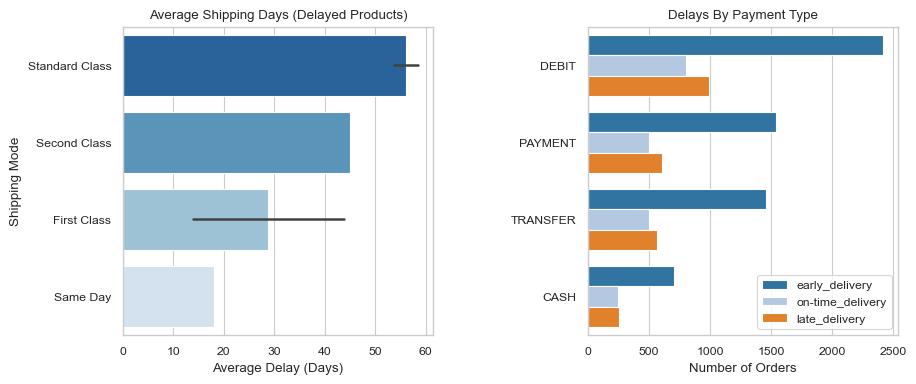

In [183]:
# Delays by shipping mode and payment type
delay_by_shipping_mode = delayed_orders.groupby('shipping_mode')['shipping_duration'].mean()
payment_and_delays = log_df[["payment_type", "delivery_delay_status"]]
order = ["DEBIT", "PAYMENT", "TRANSFER", "CASH"]
hue_order = ["early_delivery", "on-time_delivery", "late_delivery"]

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.barplot(
    data=delayed_orders,
    y="shipping_mode", 
    x="shipping_duration", 
    order=["Standard Class", "Second Class", "First Class", "Same Day"],
    palette="Blues_r",
    ax=ax[0]
).set(ylabel="Shipping Mode")

ax[0].set_title("Average Shipping Days (Delayed Products)")
ax[0].set_xlabel("Average Delay (Days)")

sns.countplot(
    data=payment_and_delays,
    y="payment_type",
    hue="delivery_delay_status",
    order=order,
    hue_order=hue_order,
    ax=ax[1],
    palette="tab20"
).set(xlabel="Number of Orders", title="Delays By Payment Type", ylabel="")

ax[1].legend(loc="lower right")

plt.subplots_adjust(wspace=0.5)
plt.savefig("Delays_by_shipping_mode_and_payment_type.png")
plt.show()

### Shipping Days According to Order Status and Payment Type

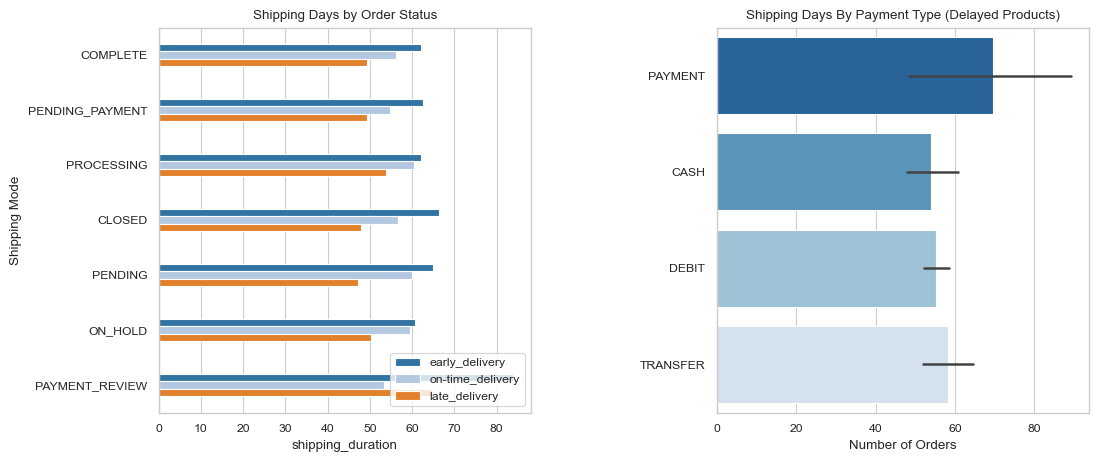

In [188]:
# Shipping days according to order status and payment_type
sorted_order_status = log_df.groupby("order_status").count().sort_values("delivery_delay_status", ascending=False).index # The sorting column is arbitrary. There was no meaning behind selecting it.

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(
    data=delayed_orders,
    y="payment_type",
    x="shipping_duration",
    order=["PAYMENT", "CASH", "DEBIT", "TRANSFER"],
#     hue_order=hue_order,
    ax=ax[1],
    palette="Blues_r"
).set(xlabel="Number of Orders", title="Shipping Days By Payment Type (Delayed Products)", ylabel="")

sns.barplot(
    data=log_df[log_df["shipping_duration"] > 0],
    y="order_status", 
    x="shipping_duration", 
    order=sorted_order_status,
    palette="tab20",
    ax=ax[0],
    hue="delivery_delay_status",
    hue_order=["early_delivery", "on-time_delivery", "late_delivery"],
    width=.4,
    errorbar=None
).set(ylabel="Shipping Mode", title="Shipping Days by Order Status")

ax[0].legend(loc="lower right", bbox_to_anchor=(1, 0))

plt.subplots_adjust(wspace=0.5)
plt.savefig("shipping_days_by_order_status_and_payment_type.png")
# plt.set_title("Average Shipping Days (Delayed Products)")
# plt.set_xlabel("Average Delay (Days)")


## Feature Engineering from product_category_id and customer_country.

### 1.  Feature Engineering for *`customer_country`*

In [190]:
# This calculates how many times each customer country appears in the dataset
country_frequency = log_df['customer_country'].value_counts(normalize=True)
log_df['customer_country_frequency'] = log_df['customer_country'].map(country_frequency)

display(log_df.head())

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,order_status,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,delivery_delay_status,shipping_duration,customer_country_frequency
0,DEBIT,34.448338,92.49099,9.0,Cardio Equipment,Caguas,Puerto Rico,12097.6830,Consumer,PR,...,COMPLETE,191.00000,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2015-08-12 23:00:00+00:00,Standard Class,late_delivery,1,0.399962
1,TRANSFER,91.193540,181.99008,48.0,Water Sports,Albuquerque,EE. UU.,5108.1045,Consumer,CA,...,PENDING,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2017-04-08 23:00:00+00:00,Standard Class,late_delivery,57,0.600038
2,DEBIT,8.313806,89.96643,46.0,Indoor/Outdoor Games,Amarillo,Puerto Rico,4293.4478,Consumer,PR,...,COMPLETE,1014.00000,46.0,O'Brien Men's Neoprene Life Vest,49.98,2015-03-18 00:00:00+00:00,Second Class,early_delivery,76,0.399962
4,DEBIT,44.722590,170.97824,48.0,Water Sports,Peabody,EE. UU.,1546.3980,Consumer,CA,...,COMPLETE,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2015-03-29 23:00:00+00:00,Standard Class,early_delivery,1,0.600038
5,CASH,76.100400,137.45360,17.0,Electronics,Caguas,Puerto Rico,5048.3975,Consumer,PR,...,CLOSED,209.90128,9.0,Under Armour Women's Ignite PIP VI Slide,39.99,2016-10-13 23:00:00+00:00,Standard Class,early_delivery,130,0.399962


In [194]:
country_frequency

customer_country
EE. UU.        0.600038
Puerto Rico    0.399962
Name: proportion, dtype: float64

### 2. Feature Engineering: Number of Unique Product Categories per Customer Country

In [191]:
# This counts how many distinct product categories are associated with each customer country
unique_categories_per_country = log_df.groupby('customer_country')['product_category_id'].nunique().reset_index()
unique_categories_per_country.rename(columns={'product_category_id': 'num_unique_product_categories_per_country'}, inplace=True)
log_df = pd.merge(log_df, unique_categories_per_country, on='customer_country', how='left')

log_df.head()

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,product_card_id,product_category_id,product_name,product_price,shipping_date,shipping_mode,delivery_delay_status,shipping_duration,customer_country_frequency,num_unique_product_categories_per_country
0,DEBIT,34.448338,92.49099,9.0,Cardio Equipment,Caguas,Puerto Rico,12097.6830,Consumer,PR,...,191.00000,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2015-08-12 23:00:00+00:00,Standard Class,late_delivery,1,0.399962,147
1,TRANSFER,91.193540,181.99008,48.0,Water Sports,Albuquerque,EE. UU.,5108.1045,Consumer,CA,...,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2017-04-08 23:00:00+00:00,Standard Class,late_delivery,57,0.600038,189
2,DEBIT,8.313806,89.96643,46.0,Indoor/Outdoor Games,Amarillo,Puerto Rico,4293.4478,Consumer,PR,...,1014.00000,46.0,O'Brien Men's Neoprene Life Vest,49.98,2015-03-18 00:00:00+00:00,Second Class,early_delivery,76,0.399962,147
3,DEBIT,44.722590,170.97824,48.0,Water Sports,Peabody,EE. UU.,1546.3980,Consumer,CA,...,1073.00000,48.0,Pelican Sunstream 100 Kayak,199.99,2015-03-29 23:00:00+00:00,Standard Class,early_delivery,1,0.600038,189
4,CASH,76.100400,137.45360,17.0,Electronics,Caguas,Puerto Rico,5048.3975,Consumer,PR,...,209.90128,9.0,Under Armour Women's Ignite PIP VI Slide,39.99,2016-10-13 23:00:00+00:00,Standard Class,early_delivery,130,0.399962,147


In [193]:
unique_categories_per_country

,customer_country,num_unique_product_categories_per_country
0,EE. UU.,189
1,Puerto Rico,147


### 3. Feature Engineering: Number of Unique Customer Countries per Product Category

In [195]:
# This counts how many distinct customer countries order each product category
unique_countries_per_category = log_df.groupby('product_category_id')['customer_country'].nunique().reset_index()
unique_countries_per_category.rename(columns={'customer_country': 'num_unique_customer_countries_per_category'}, inplace=True)
log_df = pd.merge(log_df, unique_countries_per_category, on='product_category_id', how='left')

log_df.head()

,payment_type,profit_per_order,sales_per_customer,category_id,category_name,customer_city,customer_country,customer_id,customer_segment,customer_state,...,product_category_id,product_name,product_price,shipping_date,shipping_mode,delivery_delay_status,shipping_duration,customer_country_frequency,num_unique_product_categories_per_country,num_unique_customer_countries_per_category
0,DEBIT,34.448338,92.49099,9.0,Cardio Equipment,Caguas,Puerto Rico,12097.6830,Consumer,PR,...,9.0,Nike Men's Free 5.0+ Running Shoe,99.99,2015-08-12 23:00:00+00:00,Standard Class,late_delivery,1,0.399962,147,2
1,TRANSFER,91.193540,181.99008,48.0,Water Sports,Albuquerque,EE. UU.,5108.1045,Consumer,CA,...,48.0,Pelican Sunstream 100 Kayak,199.99,2017-04-08 23:00:00+00:00,Standard Class,late_delivery,57,0.600038,189,2
2,DEBIT,8.313806,89.96643,46.0,Indoor/Outdoor Games,Amarillo,Puerto Rico,4293.4478,Consumer,PR,...,46.0,O'Brien Men's Neoprene Life Vest,49.98,2015-03-18 00:00:00+00:00,Second Class,early_delivery,76,0.399962,147,2
3,DEBIT,44.722590,170.97824,48.0,Water Sports,Peabody,EE. UU.,1546.3980,Consumer,CA,...,48.0,Pelican Sunstream 100 Kayak,199.99,2015-03-29 23:00:00+00:00,Standard Class,early_delivery,1,0.600038,189,2
4,CASH,76.100400,137.45360,17.0,Electronics,Caguas,Puerto Rico,5048.3975,Consumer,PR,...,9.0,Under Armour Women's Ignite PIP VI Slide,39.99,2016-10-13 23:00:00+00:00,Standard Class,early_delivery,130,0.399962,147,2


In [196]:
unique_countries_per_category

,product_category_id,num_unique_customer_countries_per_category
0,2.000000,1
1,2.000204,1
2,2.000205,1
3,2.000635,1
4,2.000838,1
...,...,...
295,74.000000,2
296,75.000000,2
297,75.605840,1
298,75.854450,1


In [199]:
## Display the first few rows with the new features

# Select original columns and newly engineered features for display
columns_to_display = [
    'customer_country',
    'product_category_id',
    'customer_country_frequency',
    'num_unique_product_categories_per_country',
    'num_unique_customer_countries_per_category'
]

display(log_df[columns_to_display].head())

,customer_country,product_category_id,customer_country_frequency,num_unique_product_categories_per_country,num_unique_customer_countries_per_category
0,Puerto Rico,9.0,0.399962,147,2
1,EE. UU.,48.0,0.600038,189,2
2,Puerto Rico,46.0,0.399962,147,2
3,EE. UU.,48.0,0.600038,189,2
4,Puerto Rico,9.0,0.399962,147,2


## **Interpretation of the Newly Engineered Features**

Here are the new features that have been created:

- **customer_country_frequency**: This feature represents the frequency of each customer_country in the dataset. It provides a numerical value indicating how common a particular country is among the customer base. For example, 'Puerto Rico' has a frequency of `0.399962`, and 'EE. UU.' has a frequency of `0.600038`, which suggests a higher proportion of customers from 'EE. UU.' in this dataset.

- **num_unique_product_categories_per_country**: This feature indicates the number of unique product_category_id values associated with each customer_country. It helps to understand the diversity of products ordered by customers in a given country. For instance, customers in 'Puerto Rico' have purchased from `147` different product categories, while those in 'EE. UU.' have purchased from `189` categories.

- **num_unique_customer_countries_per_category**: This feature represents the number of unique customer_country values for each product_category_id. This metric can help identify how widely a particular product category is distributed across different countries. For example, for product_category_id 9, 48, 46, and 17, there are `2` unique customer countries associated with them.

These new features can be valuable for building more robust predictive models, as they capture additional insights from the original categorical variables. For instance, customer_country_frequency could be used as an indicator of market size, while the unique category/country counts can help understand product popularity and market reach.

## Feature Encoding, Scaling and Model Development

### Feature Encoding

In [200]:
# Drop columns that are unlikely to be directly predictive or are duplicates of others,
# or are identifiers (e.g., IDs, names that aren't categories)
# Also drop 'shipping_date' and 'order_date' as they are datetime objects, will need to be engineered if used
# Drop 'customer_zipcode' which is text, could be problematic if not numericalized
# Drop 'product_name' and 'category_name' as we have their IDs.
# Drop 'customer_city', 'customer_state', 'order_city', 'order_state' as we have higher level location like 'customer_country', 'order_region'
# Drop 'latitude', 'longitude' as market and region provides geographical context

columns_to_drop = [
    'category_name', 'customer_zipcode', 'department_name',
    'product_name', 'shipping_date', 'order_date',
    'customer_id', 'order_customer_id', 'order_id', 'order_item_cardprod_id',
    'order_item_id', 'product_card_id', 'product_category_id', # Keeping product_category_id for now as it's a feature, if it's too many unique values for OHE, will reconsider
    'category_id', 'department_id',
    'customer_city', 'customer_state', 'order_city', 'order_state'
]

log_df = log_df.drop(columns=columns_to_drop, errors='ignore')

In [201]:
log_df.shape

(10596, 26)

In [203]:
from sklearn.preprocessing import LabelEncoder

# Encode target variable
label_encoder = LabelEncoder()
log_df["delivery_delay_status"] = label_encoder.fit_transform(log_df["delivery_delay_status"])  # 0,1,2

In [204]:
log_df['delivery_delay_status']

0        1
1        1
2        0
3        0
4        0
        ..
10591    1
10592    0
10593    2
10594    1
10595    2
Name: delivery_delay_status, Length: 10596, dtype: int64

In [219]:
# Separate features (X) and target variable (y)
X = log_df.drop(columns=["delivery_delay_status"])
y = log_df["delivery_delay_status"]

In [220]:
from sklearn.preprocessing import OneHotEncoder

cat_features = X.select_dtypes(include=['object'])

# Encode categorical features
onehot = OneHotEncoder(drop='first',
        handle_unknown='ignore',
        sparse_output=False)

X_encoded = pd.DataFrame(onehot.fit_transform(cat_features),
                         columns=onehot.get_feature_names_out(),
                         index=cat_features.index)

X_encoded

,payment_type_DEBIT,payment_type_PAYMENT,payment_type_TRANSFER,customer_country_Puerto Rico,customer_segment_Corporate,customer_segment_Home Office,market_Europe,market_LATAM,market_Pacific Asia,market_USCA,...,order_region_Western Europe,order_status_COMPLETE,order_status_ON_HOLD,order_status_PAYMENT_REVIEW,order_status_PENDING,order_status_PENDING_PAYMENT,order_status_PROCESSING,shipping_mode_Same Day,shipping_mode_Second Class,shipping_mode_Standard Class
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10591,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10592,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
10593,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10594,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [224]:
from sklearn.preprocessing import StandardScaler

num_features = X.select_dtypes(include=['float64', 'int64'])

# Scale Numerical Features
std_scaler = StandardScaler()

X_scaled = pd.DataFrame(std_scaler.fit_transform(num_features),
                        columns=std_scaler.get_feature_names_out(),
                        index=num_features.index)
X_scaled.head()

,profit_per_order,sales_per_customer,latitude,longitude,order_item_discount,order_item_discount_rate,order_item_product_price,order_item_profit_ratio,order_item_quantity,sales,order_item_total_amount,order_profit_per_order,product_price,shipping_duration,customer_country_frequency,num_unique_product_categories_per_country,num_unique_customer_countries_per_category
0,0.028824,-0.674372,-1.145742,0.886314,-0.210420,0.392290,0.313829,0.838792,-0.912118,-0.730415,-0.799307,-0.063460,0.314283,-0.074754,-1.224841,-1.224841,0.162009
1,1.882129,0.764722,0.817297,-1.859577,0.082227,-0.473114,2.166445,1.207529,-0.912118,0.738388,0.764416,1.859012,2.166603,0.537114,0.816432,0.816432,0.162009
2,-0.824733,-0.714966,-1.152357,0.903042,-0.665119,-0.617348,-0.612664,-0.846861,-0.224913,-0.730856,-0.657142,-0.879786,-0.612062,0.744713,-1.224841,-1.224841,0.162009
3,0.364382,0.587657,0.927577,-1.919766,1.100580,0.680758,2.166445,0.101319,-0.912118,0.738388,0.588468,0.342332,2.166603,-0.074754,0.816432,0.816432,0.162009
4,1.389185,0.048601,-1.154934,0.886318,-1.163350,-1.482752,-0.797740,1.260206,1.149498,-0.289774,0.175565,1.529202,-0.797109,1.334729,-1.224841,-1.224841,0.162009


In [226]:
# Concatenate X_encoded and X_scaled into X dataframe
X = pd.concat([X_encoded, X_scaled], axis=1)

X.head()

,payment_type_DEBIT,payment_type_PAYMENT,payment_type_TRANSFER,customer_country_Puerto Rico,customer_segment_Corporate,customer_segment_Home Office,market_Europe,market_LATAM,market_Pacific Asia,market_USCA,...,order_item_profit_ratio,order_item_quantity,sales,order_item_total_amount,order_profit_per_order,product_price,shipping_duration,customer_country_frequency,num_unique_product_categories_per_country,num_unique_customer_countries_per_category
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.838792,-0.912118,-0.730415,-0.799307,-0.063460,0.314283,-0.074754,-1.224841,-1.224841,0.162009
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.207529,-0.912118,0.738388,0.764416,1.859012,2.166603,0.537114,0.816432,0.816432,0.162009
2,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-0.846861,-0.224913,-0.730856,-0.657142,-0.879786,-0.612062,0.744713,-1.224841,-1.224841,0.162009
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.101319,-0.912118,0.738388,0.588468,0.342332,2.166603,-0.074754,0.816432,0.816432,0.162009
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.260206,1.149498,-0.289774,0.175565,1.529202,-0.797109,1.334729,-1.224841,-1.224841,0.162009


## Model Development

### Split the dataset into training and testing set

In [227]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8476, 201) (2120, 201)
(8476,) (2120,)


## Model Training and Evaluation

In [233]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score

## Model Performance Evaluation

# Define models to train and evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": LinearSVC(),
    "XGB": XGBClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'accuracy': acc,
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
        'classification_report': report
    }

results

{'Logistic Regression': {'accuracy': 0.5533018867924528,
  'F1 Score': 0.4989506005800161,
  'classification_report': {'0': {'precision': 0.6219126029132362,
    'recall': 0.8036006546644845,
    'f1-score': 0.7011781506604784,
    'support': 1222.0},
   '1': {'precision': 0.363265306122449,
    'recall': 0.36400817995910023,
    'f1-score': 0.36363636363636365,
    'support': 489.0},
   '2': {'precision': 0.2549019607843137,
    'recall': 0.03178484107579462,
    'f1-score': 0.05652173913043478,
    'support': 409.0},
   'accuracy': 0.5533018867924528,
   'macro avg': {'precision': 0.4133599566066663,
    'recall': 0.3997978918997931,
    'f1-score': 0.3737787511424256,
    'support': 2120.0},
   'weighted avg': {'precision': 0.4914475648182248,
    'recall': 0.5533018867924528,
    'f1-score': 0.4989506005800161,
    'support': 2120.0}}},
 'Decision Tree': {'accuracy': 0.5278301886792452,
  'F1 Score': 0.526531306486942,
  'classification_report': {'0': {'precision': 0.68003207698476

## Insight
Based on the model evaluation results, the best performing model overall is ***Gradient Boosting Classifier***.

| Model                 | Accuracy | F1 Score (Weighted) | Notes                            |
|-----------------------|----------|----------------------|----------------------------------|
| **Gradient Boosting** | **0.609**| **0.572**            | Highest F1 and accuracy          |
| XGBoost               | 0.590    | 0.560                | Close second                     |
| Random Forest         | 0.593    | 0.527                | Decent accuracy, lower F1        |
| Logistic Regression   | 0.553    | 0.499                | Lower on both                    |
| SVM (Linear)          | 0.555    | 0.501                | Similar to Logistic Regression   |
| Decision Tree         | 0.528    | 0.527                | OK F1 but lower accuracy         |
| KNN                   | 0.539    | 0.484                | Lower metrics                    |
| Naive Bayes           | 0.200    | 0.093                | Performs very poorly             |

### Why Gradient Boosting Wins:
- **Balanced Performance**: Gradient Boosting achieves the best trade-off between precision, recall, and F1 across all classes.

- **High Accuracy**: Slightly better accuracy than XGBoost, which usually indicates it generalizes better on this test set.

- **Better handling of class 1 (Delayed)**: It has higher recall and precision for the delayed class than most models.

In [235]:
# The target variable classes and corresponding labels
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i}: {cls}")

0: early_delivery
1: late_delivery
2: on-time_delivery


### Retraining the best model, evaluating and printing its classification Report - ***Gradient Boosting Classifier***

In [236]:
# Collect evaluation metrics for the best model (Gradient Boosting)
from sklearn.metrics import classification_report

# Retraining Gradient Boosting
best_model = GradientBoostingClassifier()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

                  precision    recall  f1-score   support

  early_delivery       0.71      0.78      0.74      1222
   late_delivery       0.43      0.63      0.51       489
on-time_delivery       0.54      0.08      0.13       409

        accuracy                           0.61      2120
       macro avg       0.56      0.50      0.46      2120
    weighted avg       0.61      0.61      0.57      2120



### Hyperparameter tuning using GridSearchCV

In [250]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid = GridSearchCV(
    GradientBoostingClassifier(),
    param_grid,
    cv=3,
    scoring='f1_weighted'
)

grid.fit(X_train, y_train)
tuned_model = grid.best_estimator_

In [251]:
# Predictions from the best tuned model
y_pred_tuned = tuned_model.predict(X_test)

# Compare classification report
print("Tuned Model Performance:")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

# Accuracy comparison
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Model Performance:
                  precision    recall  f1-score   support

  early_delivery       0.71      0.78      0.74      1222
   late_delivery       0.43      0.63      0.51       489
on-time_delivery       0.54      0.08      0.13       409

        accuracy                           0.61      2120
       macro avg       0.56      0.50      0.46      2120
    weighted avg       0.61      0.61      0.57      2120

Tuned Accuracy: 0.6099056603773585


### Confusion Matrix

In [252]:
metrics.confusion_matrix(y_test, y_pred_tuned)

array([[952, 252,  18],
       [171, 310,   8],
       [218, 160,  31]])

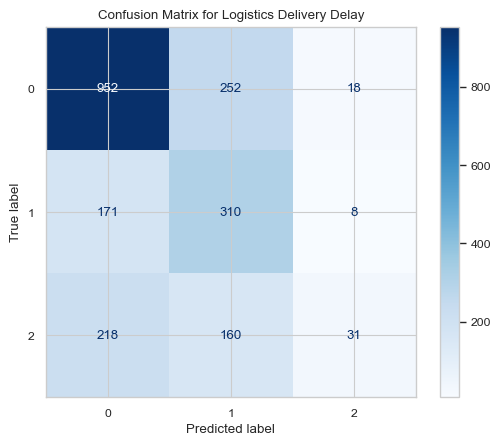

In [270]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the predictions
y_pred = tuned_model.predict(X_test)

# Generating the confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
labels = tuned_model.classes_

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Logistics Delivery Delay")

plt.show()

## Interpretation
### Let’s go row-by-row:

**Row 1**: Actual = early_delivery
- Predicted as early_delivery: 952 (✅ correct)

- Predicted as late_delivery: 252 (❌ misclassified)

- Predicted as on-time_delivery: 18 (❌ misclassified)

→ Conclusion: While most early deliveries were classified correctly, 252 were misclassified as late, which could indicate some overlap in feature patterns.

**Row 2**: Actual = late_delivery
- Predicted as early_delivery: 171 (❌)

- Predicted as late_delivery: 310 (✅ correct)

- Predicted as on-time_delivery: 8 (❌)

→ Conclusion: Around 63% of late deliveries were correctly identified. However, 171 were wrongly predicted as early, which may reduce trust in the model for critical late delivery identification.

**Row 3**: Actual = on-time_delivery
- Predicted as early_delivery: 218 (❌)

- Predicted as late_delivery: 160 (❌)

- Predicted as on-time_delivery: 31 (✅ correct)

→ Conclusion: Most of the on-time deliveries were misclassified as either early or late. Only 31/409 (~7.6%) were correctly predicted — this shows the model struggles to detect on-time deliveries accurately.

>### Summary Table

| Actual \ Predicted | Early | Late | On-time | Total Actual | Accuracy per Class |
|--------------------|-------|------|---------|---------------|---------------------|
| Early              | 952   | 252  | 18      | 1222          | 77.9%               |
| Late               | 171   | 310  | 8       | 489           | 63.4%               |
| On-time            | 218   | 160  | 31      | 409           | 7.6%                |

## Insights:
The model performs best on early deliveries, moderately on late deliveries, and very poorly on on-time deliveries.

**This suggests**:

- Our data may not have distinct features that differentiate on-time from the others.

- There's a class imbalance, or the features used don’t adequately represent on-time patterns.


### Heatmap of Actual vs Predicted

Text(0.5, 25.71666666666666, 'Predicted')

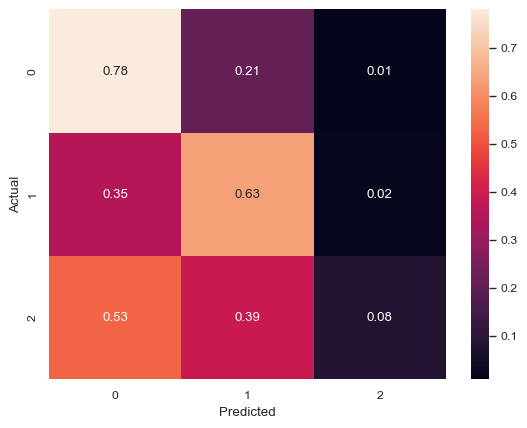

In [255]:
actual = np.sum(cm, axis=1).reshape(-1,1)
cmn = np.round(cm/actual, 2)

sns.heatmap(cmn, annot=True, fmt='.2f', xticklabels=tuned_model.classes_, yticklabels=tuned_model.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')

### What the Chart Represents

a. Axes:

    - The rows represent the actual classes (ground truth labels).
    - The columns represent the predicted classes (output from the classification model).

b. Diagonal Cells:

The diagonal cells (top-left to bottom-right) indicate the proportion of correct predictions for each class. For example, the model correctly predicted:
- 78% of Early Deliveries were classified as Early Deliveries.
- 63% of Late Deliveries were classified as Late Deliveries.
- 8% of On-time Deliveries were classified as On-time Deliveries

c. Off-Diagonal Cells:

The off-diagonal cells indicate the proportion of misclassifications (where the model predicted the wrong class).
<hr><hr>

## Feature Importance - Top Features contributing to delivery delays

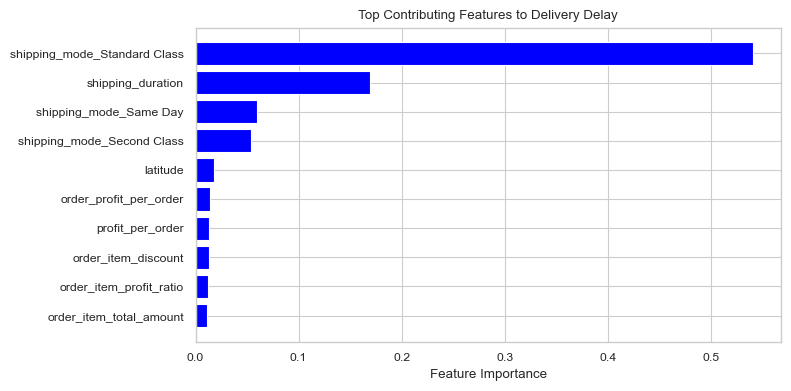

In [262]:
# Get feature importances from the best model
importances = tuned_model.feature_importances_

# Match to column names
feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Select top 10 features
top_10_features = importance_df.head(10)

# Plot top features
plt.figure(figsize=(8, 4))
plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.title('Top Contributing Features to Delivery Delay')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [264]:
top_10_features

,Feature,Importance
183,shipping_mode_Standard Class,0.541267
197,shipping_duration,0.169604
181,shipping_mode_Same Day,0.059593
182,shipping_mode_Second Class,0.053498
186,latitude,0.018282
195,order_profit_per_order,0.014528
184,profit_per_order,0.013542
188,order_item_discount,0.013062
191,order_item_profit_ratio,0.011888
194,order_item_total_amount,0.011457


<hr>

# Summary Report Highlighting Actionable Recommendations to Reduce Delays

## Delivery Delay Analysis Report
### Overview
A machine learning model was trained to predict delivery delay statuses using various features from the dataset. The Gradient Boosting classifier, after hyperparameter tuning and resampling, highlighted the top 10 predictors of delivery delays. These features and their importance scores are listed above.

## Key Findings & Recommendations
### 1. Standard Class Shipping Mode (Highest Impact)

- This mode is strongly correlated with delivery delays.

**Recommendation**: Reassess the logistics partners and processes associated with Standard Class. Optimize routes, vendor timelines, and warehousing to reduce latency.

### 2. Shipping Duration

- Longer estimated shipping durations are linked to higher delay likelihood.

**Recommendation**: Reduce shipping duration estimates or improve fulfillment speed through warehouse automation or regional distribution centers.

### 3. Other Shipping Modes (Same Day, Second Class)

- Same Day and Second Class modes also contribute to predictions, though less than Standard Class.

**Recommendation**: Invest in improving real-time tracking and fulfillment speed across all modes. Promote reliable shipping modes with proven on-time records.

### 4. Latitude

- Geographic location (likely destination-based) has a moderate impact.

**Recommendation**: Analyze geographic patterns of delays. Consider adding local fulfillment centers or partnering with local couriers in regions with frequent delays.

### 5. Order Profit & Profit Ratios

- Orders with low profit margins or high item costs have slightly higher risk.

**Recommendation**: For high-value orders, offer priority processing. Use profitability insights to determine when to invest in faster shipping.

### 6. Item Discount

Heavily discounted orders might correlate with bulk sales or promotions causing fulfillment strain.

**Recommendation**: Monitor operational load during sales campaigns. Avoid overwhelming fulfillment systems during discounts.

## What's Next?
- A/B Test new shipping strategies for Standard Class orders.

- Implement early warning systems for long-duration shipments.

- Re-evaluate pricing and discount policies from an operations standpoint.

- Explore geographic delivery challenges using latitude-based clustering.

